# 第三阶段：多模型建模与性能优化


## 准备：环境与路径配置


In [41]:
# 统一导入本阶段需要的建模、评估、画图和路径配置工具。
from pathlib import Path
from time import perf_counter
import sys

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import shap
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier


RANDOM_STATE = 42

CURRENT_DIR = Path.cwd()
NOTEBOOK_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
SRC_PATH = NOTEBOOK_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from config import (
    FEATURE_PARQUET_PATH,
    PROJECT_ROOT,
    TARGET_COLUMN,
    TEST_DATASET_PATH,
    TRAIN_DATASET_PATH,
    VALIDATION_DATASET_PATH,
)


SPLIT_SUMMARY_PATH = PROJECT_ROOT / "reports" / "stage3_sample_split_summary.csv"
SAMPLING_COMPARISON_PATH = PROJECT_ROOT / "reports" / "stage3_sampling_strategy_comparison.csv"
HOTEL_TYPE_SPLIT_SUMMARY_PATH = PROJECT_ROOT / "reports" / "stage3_hotel_type_split_summary.csv"
HOTEL_TYPE_MODEL_METRICS_PATH = PROJECT_ROOT / "reports" / "hotel_type_model_performance.csv"

STAGE3_CITY_TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "stage3_city_train.parquet"
STAGE3_CITY_VALIDATION_PATH = PROJECT_ROOT / "data" / "processed" / "stage3_city_validation.parquet"
STAGE3_CITY_TEST_PATH = PROJECT_ROOT / "data" / "processed" / "stage3_city_test.parquet"
STAGE3_RESORT_TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "stage3_resort_train.parquet"
STAGE3_RESORT_VALIDATION_PATH = PROJECT_ROOT / "data" / "processed" / "stage3_resort_validation.parquet"
STAGE3_RESORT_TEST_PATH = PROJECT_ROOT / "data" / "processed" / "stage3_resort_test.parquet"

BASELINE_METRICS_PATH = PROJECT_ROOT / "reports" / "traditional_ml_model_metrics.csv"
BASELINE_FEATURE_INFO_PATH = PROJECT_ROOT / "reports" / "traditional_ml_feature_info.csv"

OPTUNA_BEST_PARAMS_PATH = PROJECT_ROOT / "reports" / "optuna_best_params.csv"
OPTUNA_TUNING_RESULTS_PATH = PROJECT_ROOT / "reports" / "optuna_tuning_results.csv"
OPTUNA_MODEL_METRICS_PATH = PROJECT_ROOT / "reports" / "optuna_model_metrics.csv"

PERFORMANCE_SUMMARY_PATH = PROJECT_ROOT / "reports" / "traditional_model_performance_comparison.csv"
TUNING_COMPARISON_PATH = PROJECT_ROOT / "reports" / "traditional_model_tuning_comparison.csv"
TUNING_COMPARISON_FIGURE_PATH = PROJECT_ROOT / "reports" / "traditional_model_tuning_comparison.png"
MODEL_ANALYSIS_PATH = PROJECT_ROOT / "reports" / "traditional_model_advantage_analysis.csv"
AUC_FIGURE_PATH = PROJECT_ROOT / "reports" / "traditional_model_auc_comparison.png"
METRICS_FIGURE_PATH = PROJECT_ROOT / "reports" / "traditional_model_metrics_comparison.png"

DEEP_LEARNING_METRICS_PATH = PROJECT_ROOT / "reports" / "deep_learning_model_metrics.csv"
DEEP_LEARNING_TUNING_PATH = PROJECT_ROOT / "reports" / "deep_learning_tuning_results.csv"
DEEP_LEARNING_COMPARISON_PATH = PROJECT_ROOT / "reports" / "deep_learning_model_comparison.csv"
DEEP_LEARNING_AUC_FIGURE_PATH = PROJECT_ROOT / "reports" / "deep_learning_auc_comparison.png"
DEEP_LEARNING_HISTORY_PATH = PROJECT_ROOT / "reports" / "deep_learning_training_history.csv"
MLP_TRAINING_CURVE_PATH = PROJECT_ROOT / "reports" / "mlp_training_curve.png"
EMBEDDING_MLP_TRAINING_CURVE_PATH = PROJECT_ROOT / "reports" / "embedding_mlp_training_curve.png"
MLP_PREDICTION_PATH = PROJECT_ROOT / "reports" / "mlp_prediction_probabilities.csv"

ENSEMBLE_MODEL_METRICS_PATH = PROJECT_ROOT / "reports" / "ensemble_model_metrics.csv"
ENSEMBLE_MODEL_COMPARISON_PATH = PROJECT_ROOT / "reports" / "ensemble_model_comparison.csv"
ENSEMBLE_MODEL_COMPARISON_FIGURE_PATH = PROJECT_ROOT / "reports" / "ensemble_model_comparison.png"
ENSEMBLE_MODEL_PREDICTION_PATH = PROJECT_ROOT / "reports" / "ensemble_model_predictions.csv"
LOGISTIC_COEFFICIENT_PATH = PROJECT_ROOT / "reports" / "logistic_regression_coefficients.csv"
LOGISTIC_COEFFICIENT_FIGURE_PATH = PROJECT_ROOT / "reports" / "logistic_regression_coefficients_top20.png"
SHAP_IMPORTANCE_PATH = PROJECT_ROOT / "reports" / "shap_feature_importance.csv"
SHAP_XGBOOST_FIGURE_PATH = PROJECT_ROOT / "reports" / "shap_xgboost_top20.png"
SHAP_LIGHTGBM_FIGURE_PATH = PROJECT_ROOT / "reports" / "shap_lightgbm_top20.png"
CORE_FEATURE_TOP10_PATH = PROJECT_ROOT / "reports" / "core_feature_top10.csv"
CORE_FEATURE_TOP10_FIGURE_PATH = PROJECT_ROOT / "reports" / "core_feature_top10.png"
ERROR_SAMPLE_ANALYSIS_PATH = PROJECT_ROOT / "reports" / "prediction_error_samples.csv"
ERROR_SEGMENT_SUMMARY_PATH = PROJECT_ROOT / "reports" / "prediction_error_segment_summary.csv"
ERROR_SCENARIO_SUMMARY_PATH = PROJECT_ROOT / "reports" / "prediction_error_scenario_summary.csv"
ERROR_TYPE_FIGURE_PATH = PROJECT_ROOT / "reports" / "prediction_error_type_distribution.png"
ERROR_SCENARIO_FIGURE_PATH = PROJECT_ROOT / "reports" / "prediction_error_scenario_rate.png"

BUSINESS_RISK_SCORE_PATH = PROJECT_ROOT / "reports" / "business_risk_scores.csv"
BUSINESS_THRESHOLD_SIMULATION_PATH = PROJECT_ROOT / "reports" / "business_threshold_simulation.csv"
BUSINESS_RISK_SEGMENT_SUMMARY_PATH = PROJECT_ROOT / "reports" / "business_risk_segment_summary.csv"
BUSINESS_THRESHOLD_FIGURE_PATH = PROJECT_ROOT / "reports" / "business_threshold_simulation.png"
BUSINESS_RISK_SEGMENT_FIGURE_PATH = PROJECT_ROOT / "reports" / "business_risk_segment_summary.png"

# 数据划分、传统模型调优和深度学习训练结果已经生成。
# 默认关闭长时间训练；如需重新训练或重新调参，再将对应开关改为 True。
RUN_BASELINE_TRAINING = False
RUN_OPTUNA_TUNING = False
RUN_HOTEL_TYPE_EVALUATION = False
RUN_DEEP_LEARNING_TRAINING = False
RUN_EMBEDDING_TRAINING = False
RUN_MODEL_FUSION_EXPLAINABILITY = False
RUN_BUSINESS_SIMULATION = False

optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

CHINESE_FONT = "Microsoft YaHei"
plt.rcParams["font.family"] = CHINESE_FONT
plt.rcParams["font.sans-serif"] = [
    CHINESE_FONT,
    "SimHei",
    "SimSun",
    "Arial Unicode MS",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


## 1. 样本构建与数据集划分


In [42]:
# 读取第二阶段已经切分好的训练集、验证集和测试集。
for path in [TRAIN_DATASET_PATH, VALIDATION_DATASET_PATH, TEST_DATASET_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"第二阶段建模数据不存在：{path.relative_to(PROJECT_ROOT)}")

train_df = pd.read_parquet(TRAIN_DATASET_PATH)
validation_df = pd.read_parquet(VALIDATION_DATASET_PATH)
test_df = pd.read_parquet(TEST_DATASET_PATH)

print("数据划分已在第二阶段完成，本阶段直接沿用相同的训练集、验证集和测试集。")
print(f"训练集：{train_df.shape[0]:,} 行，{train_df.shape[1]:,} 列")
print(f"验证集：{validation_df.shape[0]:,} 行，{validation_df.shape[1]:,} 列")
print(f"测试集：{test_df.shape[0]:,} 行，{test_df.shape[1]:,} 列")


数据划分已在第二阶段完成，本阶段直接沿用相同的训练集、验证集和测试集。
训练集：74,132 行，169 列
验证集：18,628 行，169 列
测试集：17,868 行，169 列


In [43]:
# 汇总三份数据的样本量和取消率，检查时间窗口划分后的类别分布。
def build_split_summary(frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    """统计每个数据集的样本量、取消样本量和取消率。"""
    records = []
    for split_name, split_df in frames.items():
        class_counts = split_df[TARGET_COLUMN].value_counts().to_dict()
        total_count = split_df.shape[0]
        canceled_count = int(class_counts.get(1, 0))
        not_canceled_count = int(class_counts.get(0, 0))
        records.append(
            {
                "dataset": split_name,
                "total_count": total_count,
                "not_canceled_count": not_canceled_count,
                "canceled_count": canceled_count,
                "not_canceled_ratio": round(not_canceled_count / total_count, 4),
                "canceled_ratio": round(canceled_count / total_count, 4),
                "data_source": "second_stage_modeling_dataset",
            }
        )
    return pd.DataFrame(records)


split_summary = build_split_summary(
    {
        "train": train_df,
        "validation": validation_df,
        "test": test_df,
    }
)
SPLIT_SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
split_summary.to_csv(SPLIT_SUMMARY_PATH, index=False, encoding="utf-8-sig")
split_summary


,dataset,total_count,not_canceled_count,canceled_count,not_canceled_ratio,canceled_ratio,data_source
0,train,74132,46712,27420,0.6301,0.3699,second_stage_modeling_dataset
1,validation,18628,11704,6924,0.6283,0.3717,second_stage_modeling_dataset
2,test,17868,11192,6676,0.6264,0.3736,second_stage_modeling_dataset


In [44]:
# 对比不同样本平衡方案在训练集上的样本数量变化。
def compare_sampling_strategies(y_train: pd.Series) -> pd.DataFrame:
    """对比原始训练集、SMOTE、欠采样和类别权重四种训练口径。"""
    class_counts = y_train.value_counts().sort_index()
    not_canceled_count = int(class_counts.get(0, 0))
    canceled_count = int(class_counts.get(1, 0))
    max_count = max(not_canceled_count, canceled_count)
    min_count = min(not_canceled_count, canceled_count)

    classes = np.array([0, 1])
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_train,
    )
    class_weight_map = {
        int(class_label): round(float(weight), 4)
        for class_label, weight in zip(classes, weights)
    }

    records = [
        {
            "strategy": "原始训练集",
            "not_canceled_count": not_canceled_count,
            "canceled_count": canceled_count,
            "total_count": not_canceled_count + canceled_count,
            "canceled_ratio": round(canceled_count / (not_canceled_count + canceled_count), 4),
            "description": "不改变样本数量，作为基线训练口径。",
        },
        {
            "strategy": "SMOTE过采样",
            "not_canceled_count": max_count,
            "canceled_count": max_count,
            "total_count": max_count * 2,
            "canceled_ratio": 0.5,
            "description": "只对训练集少数类生成合成样本，使正负样本数量一致。",
        },
        {
            "strategy": "欠采样",
            "not_canceled_count": min_count,
            "canceled_count": min_count,
            "total_count": min_count * 2,
            "canceled_ratio": 0.5,
            "description": "只对训练集多数类随机抽样，使正负样本数量一致。",
        },
        {
            "strategy": "类别权重调整",
            "not_canceled_count": not_canceled_count,
            "canceled_count": canceled_count,
            "total_count": not_canceled_count + canceled_count,
            "canceled_ratio": round(canceled_count / (not_canceled_count + canceled_count), 4),
            "description": f"不改变样本数量，class_weight={class_weight_map}。",
        },
    ]
    return pd.DataFrame(records)


sampling_strategy_comparison = compare_sampling_strategies(train_df[TARGET_COLUMN])
sampling_strategy_comparison.to_csv(
    SAMPLING_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig",
)
sampling_strategy_comparison


,strategy,not_canceled_count,canceled_count,total_count,canceled_ratio,description
0,原始训练集,46712,27420,74132,0.3699,不改变样本数量，作为基线训练口径。
1,SMOTE过采样,46712,46712,93424,0.5000,只对训练集少数类生成合成样本，使正负样本数量一致。
2,欠采样,27420,27420,54840,0.5000,只对训练集多数类随机抽样，使正负样本数量一致。
3,类别权重调整,46712,27420,74132,0.3699,"不改变样本数量，class_weight={0: 0.7935, 1: 1.3518}。"


**不平衡处理方案选择**

本项目最终选择**类别权重调整**作为当前阶段的不平衡处理方案：

- 类别权重调整不改变原始训练样本分布，不会删除真实订单，也不会生成缺少业务含义的合成订单。
- SMOTE 过采样会生成新的取消样本,会生成不存在的数据。
- 欠采样会减少大量未取消订单样本，可能损失正常预订行为的信息。

因此，SMOTE 和欠采样作为备选方案保留；当前主建模方案采用类别权重调整。

### 1.1 城市酒店与度假酒店独立样本集


In [45]:
# 第二阶段建模数据已包含 hotel_type 的 One-Hot 字段，可直接按该字段筛选酒店类型样本。
HOTEL_TYPE_COLUMNS = {
    "City Hotel": "hotel_type_City_Hotel",
    "Resort Hotel": "hotel_type_Resort_Hotel",
}

missing_hotel_type_columns = [
    col for col in HOTEL_TYPE_COLUMNS.values() if col not in train_df.columns
]
if missing_hotel_type_columns:
    raise KeyError(f"缺少酒店类型字段：{missing_hotel_type_columns}")


def filter_hotel_type(data: pd.DataFrame, hotel_type_column: str) -> pd.DataFrame:
    """按酒店类型 One-Hot 字段筛选对应样本。"""
    return data[data[hotel_type_column] == 1].copy()


city_train_df = filter_hotel_type(train_df, HOTEL_TYPE_COLUMNS["City Hotel"])
city_validation_df = filter_hotel_type(validation_df, HOTEL_TYPE_COLUMNS["City Hotel"])
city_test_df = filter_hotel_type(test_df, HOTEL_TYPE_COLUMNS["City Hotel"])

resort_train_df = filter_hotel_type(train_df, HOTEL_TYPE_COLUMNS["Resort Hotel"])
resort_validation_df = filter_hotel_type(validation_df, HOTEL_TYPE_COLUMNS["Resort Hotel"])
resort_test_df = filter_hotel_type(test_df, HOTEL_TYPE_COLUMNS["Resort Hotel"])

city_train_df.to_parquet(STAGE3_CITY_TRAIN_PATH, index=False)
city_validation_df.to_parquet(STAGE3_CITY_VALIDATION_PATH, index=False)
city_test_df.to_parquet(STAGE3_CITY_TEST_PATH, index=False)
resort_train_df.to_parquet(STAGE3_RESORT_TRAIN_PATH, index=False)
resort_validation_df.to_parquet(STAGE3_RESORT_VALIDATION_PATH, index=False)
resort_test_df.to_parquet(STAGE3_RESORT_TEST_PATH, index=False)

hotel_type_split_summary = pd.concat(
    [
        build_split_summary(
            {
                "city_train": city_train_df,
                "city_validation": city_validation_df,
                "city_test": city_test_df,
            }
        ).assign(hotel_type="City Hotel"),
        build_split_summary(
            {
                "resort_train": resort_train_df,
                "resort_validation": resort_validation_df,
                "resort_test": resort_test_df,
            }
        ).assign(hotel_type="Resort Hotel"),
    ],
    ignore_index=True,
)
hotel_type_split_summary.to_csv(
    HOTEL_TYPE_SPLIT_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)

hotel_type_split_summary[
    [
        "hotel_type",
        "dataset",
        "total_count",
        "not_canceled_count",
        "canceled_count",
        "canceled_ratio",
    ]
]

,hotel_type,dataset,total_count,not_canceled_count,canceled_count,canceled_ratio
0,City Hotel,city_train,51449,30044,21405,0.4160
1,City Hotel,city_validation,12984,7584,5400,0.4159
2,City Hotel,city_test,12401,7243,5158,0.4159
3,Resort Hotel,resort_train,22683,16668,6015,0.2652
4,Resort Hotel,resort_validation,5644,4120,1524,0.2700
5,Resort Hotel,resort_test,5467,3949,1518,0.2777


## 2. 传统机器学习模型构建与调优


In [46]:
# 拆分特征矩阵 X 和目标变量 y，后续所有模型共用同一套输入。
def prepare_xy(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """从第二阶段建模数据中拆分特征矩阵和目标变量。"""
    drop_columns = [TARGET_COLUMN, "dataset_split"]
    existing_drop_columns = [col for col in drop_columns if col in data.columns]
    x_data = data.drop(columns=existing_drop_columns).copy()
    y_data = data[TARGET_COLUMN].astype("int8")
    return x_data, y_data


X_train, y_train = prepare_xy(train_df)
X_validation, y_validation = prepare_xy(validation_df)
X_test, y_test = prepare_xy(test_df)

print(f"建模特征数：{X_train.shape[1]}")
print(f"训练集：{X_train.shape[0]:,} 行")
print(f"验证集：{X_validation.shape[0]:,} 行")
print(f"测试集：{X_test.shape[0]:,} 行")


建模特征数：167
训练集：74,132 行
验证集：18,628 行
测试集：17,868 行


### 2.1 默认参数基线模型


In [47]:
# 定义统一评估口径，保证不同模型的指标可以横向比较。
def evaluate_model(model, x_data, y_true, dataset_name: str) -> dict:
    """使用 AUC、精确率、召回率和 F1 评估二分类模型。"""
    positive_probability = model.predict_proba(x_data)[:, 1]
    y_pred = (positive_probability >= 0.5).astype(int)
    return {
        "dataset": dataset_name,
        "auc": round(roc_auc_score(y_true, positive_probability), 4),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
    }


negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=160,
        max_depth=14,
        min_samples_leaf=30,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBClassifier(
        n_estimators=180,
        max_depth=5,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=180,
        max_depth=-1,
        learning_rate=0.08,
        num_leaves=31,
        subsample=0.9,
        colsample_bytree=0.9,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=-1,
    ),
}

list(baseline_models.keys())


['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']

In [48]:
# 基线模型只作为未调参参考，默认读取已经保存的结果。
if RUN_BASELINE_TRAINING:
    baseline_metrics = []
    for model_name, model in baseline_models.items():
        start_time = perf_counter()
        model.fit(X_train, y_train)
        elapsed_seconds = perf_counter() - start_time

        for dataset_name, x_data, y_data in [
            ("validation", X_validation, y_validation),
            ("test", X_test, y_test),
        ]:
            result = evaluate_model(model, x_data, y_data, dataset_name)
            result["model"] = model_name
            result["train_seconds"] = round(elapsed_seconds, 2)
            baseline_metrics.append(result)

    baseline_model_metrics = pd.DataFrame(baseline_metrics)[
        ["model", "dataset", "auc", "accuracy", "precision", "recall", "f1", "train_seconds"]
    ]
    baseline_model_metrics.to_csv(
        BASELINE_METRICS_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    pd.DataFrame(
        [
            {"metric": "input_features", "value": X_train.shape[1]},
            {"metric": "train_rows", "value": X_train.shape[0]},
            {"metric": "validation_rows", "value": X_validation.shape[0]},
            {"metric": "test_rows", "value": X_test.shape[0]},
        ]
    ).to_csv(BASELINE_FEATURE_INFO_PATH, index=False, encoding="utf-8-sig")
else:
    baseline_model_metrics = pd.read_csv(BASELINE_METRICS_PATH)

baseline_model_metrics


,model,dataset,auc,accuracy,precision,recall,f1,train_seconds
0,Logistic Regression,validation,0.9151,0.8225,0.7207,0.8528,0.7812,9.23
1,Logistic Regression,test,0.9152,0.8073,0.6897,0.8800,0.7733,9.23
2,Random Forest,validation,0.9356,0.8598,0.8042,0.8232,0.8136,18.51
3,Random Forest,test,0.9350,0.8603,0.8054,0.8253,0.8153,18.51
4,XGBoost,validation,0.9413,0.8570,0.7801,0.8569,0.8167,9.43
5,XGBoost,test,0.9429,0.8597,0.7829,0.8643,0.8216,9.43
6,LightGBM,validation,0.9451,0.8651,0.7967,0.8553,0.8250,3.47
7,LightGBM,test,0.9465,0.8678,0.8024,0.8572,0.8289,3.47


### 2.2 Optuna 自动超参数调优


In [49]:
# 设置 Optuna 搜索次数，并定义四类传统模型的参数搜索空间。
N_TRIALS = {
    "Logistic Regression": 8,
    "Random Forest": 10,
    "XGBoost": 30,
    "LightGBM": 30,
}


def build_tuned_model(model_name: str, trial: optuna.Trial):
    """根据 trial 建立指定模型。"""
    if model_name == "Logistic Regression":
        return LogisticRegression(
            penalty=trial.suggest_categorical("penalty", ["l1", "l2"]),
            C=trial.suggest_float("C", 0.01, 20.0, log=True),
            solver="liblinear",
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )

    if model_name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 160, 420, step=40),
            max_depth=trial.suggest_int("max_depth", 8, 24),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 8, 80),
            min_samples_split=trial.suggest_int("min_samples_split", 10, 120),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5]),
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

    if model_name == "XGBoost":
        return XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 250, 800, step=50),
            max_depth=trial.suggest_int("max_depth", 3, 8),
            learning_rate=trial.suggest_float("learning_rate", 0.02, 0.16, log=True),
            subsample=trial.suggest_float("subsample", 0.7, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 1.0),
            min_child_weight=trial.suggest_float("min_child_weight", 1.0, 10.0),
            gamma=trial.suggest_float("gamma", 0.0, 4.0),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.5, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 0.2, 8.0, log=True),
            objective="binary:logistic",
            eval_metric="auc",
            tree_method="hist",
            scale_pos_weight=scale_pos_weight,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )

    if model_name == "LightGBM":
        return LGBMClassifier(
            n_estimators=trial.suggest_int("n_estimators", 250, 800, step=50),
            num_leaves=trial.suggest_int("num_leaves", 16, 96),
            max_depth=trial.suggest_int("max_depth", 3, 14),
            learning_rate=trial.suggest_float("learning_rate", 0.02, 0.16, log=True),
            subsample=trial.suggest_float("subsample", 0.7, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.7, 1.0),
            min_child_samples=trial.suggest_int("min_child_samples", 20, 180),
            reg_alpha=trial.suggest_float("reg_alpha", 1e-4, 1.5, log=True),
            reg_lambda=trial.suggest_float("reg_lambda", 0.2, 8.0, log=True),
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=-1,
        )

    raise ValueError(f"未知模型：{model_name}")


def make_objective(model_name: str):
    """返回以验证集 AUC 为优化目标的 Optuna objective。"""
    def objective(trial: optuna.Trial) -> float:
        model = build_tuned_model(model_name, trial)
        model.fit(X_train, y_train)
        validation_probability = model.predict_proba(X_validation)[:, 1]
        return roc_auc_score(y_validation, validation_probability)

    return objective


In [50]:
# 如打开开关，则重新运行 Optuna；默认读取前面已经保存的调优结果。
if RUN_OPTUNA_TUNING:
    tuning_records = []
    best_param_rows = []
    metric_rows = []

    for model_name, n_trials in N_TRIALS.items():
        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
            study_name=model_name,
        )
        start_time = perf_counter()
        study.optimize(
            make_objective(model_name),
            n_trials=n_trials,
            show_progress_bar=False,
            gc_after_trial=True,
        )
        elapsed_seconds = perf_counter() - start_time

        tuning_records.append(
            {
                "model": model_name,
                "n_trials": n_trials,
                "best_validation_auc": round(study.best_value, 6),
                "tuning_seconds": round(elapsed_seconds, 2),
                "best_params": study.best_params,
            }
        )

        best_model = build_tuned_model(model_name, study.best_trial)
        train_start = perf_counter()
        best_model.fit(X_train, y_train)
        train_seconds = perf_counter() - train_start

        for parameter_name, parameter_value in study.best_params.items():
            best_param_rows.append(
                {
                    "model": model_name,
                    "parameter": parameter_name,
                    "value": parameter_value,
                }
            )

        for dataset_name, x_data, y_data in [
            ("validation", X_validation, y_validation),
            ("test", X_test, y_test),
        ]:
            metrics = evaluate_model(best_model, x_data, y_data, dataset_name)
            metrics["model"] = model_name
            metrics["train_seconds"] = round(train_seconds, 2)
            metric_rows.append(metrics)

    pd.DataFrame(tuning_records).to_csv(
        OPTUNA_TUNING_RESULTS_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    pd.DataFrame(best_param_rows).to_csv(
        OPTUNA_BEST_PARAMS_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    pd.DataFrame(metric_rows).to_csv(
        OPTUNA_MODEL_METRICS_PATH,
        index=False,
        encoding="utf-8-sig",
    )

optuna_tuning_results = pd.read_csv(OPTUNA_TUNING_RESULTS_PATH)
optuna_best_params = pd.read_csv(OPTUNA_BEST_PARAMS_PATH)
optuna_model_metrics = pd.read_csv(OPTUNA_MODEL_METRICS_PATH)

optuna_tuning_results


,model,n_trials,best_validation_auc,tuning_seconds,best_params
0,Logistic Regression,8,0.915197,276.91,"{'penalty': 'l1', 'C': 1.0465133152078552}"
1,Random Forest,10,0.941450,776.34,"{'n_estimators': 160, 'max_depth': 23, 'min_sa..."
2,XGBoost,30,0.947243,556.74,"{'n_estimators': 750, 'max_depth': 8, 'learnin..."
3,LightGBM,30,0.947896,326.03,"{'n_estimators': 750, 'num_leaves': 61, 'max_d..."


### 2.3 调优前后效果对比


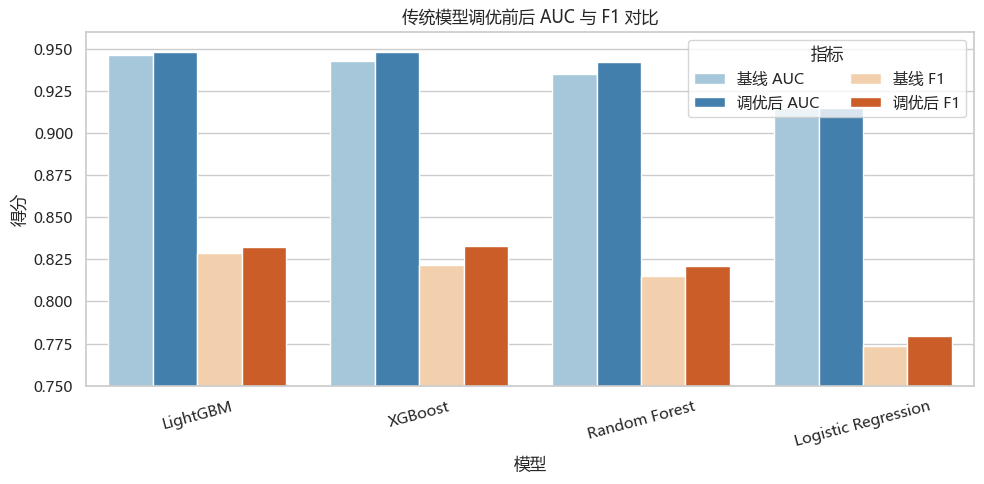

,model,baseline_auc,tuned_auc,auc_change,baseline_f1,tuned_f1,f1_change,baseline_precision,tuned_precision,precision_change,baseline_recall,tuned_recall,recall_change
0,LightGBM,0.9465,0.9485,0.0020,0.8289,0.8326,0.0037,0.8024,0.8113,0.0089,0.8572,0.8552,-0.0020
1,XGBoost,0.9429,0.9483,0.0054,0.8216,0.8329,0.0113,0.7829,0.8135,0.0306,0.8643,0.8532,-0.0111
2,Random Forest,0.9350,0.9422,0.0072,0.8153,0.8209,0.0056,0.8054,0.8074,0.0020,0.8253,0.8348,0.0095
3,Logistic Regression,0.9152,0.9152,0.0000,0.7733,0.7795,0.0062,0.6897,0.7175,0.0278,0.8800,0.8532,-0.0268


In [51]:
# 比较未经过 Optuna 搜索的基线模型和 Optuna 调优后的模型表现。
baseline_test_metrics = baseline_model_metrics[
    baseline_model_metrics["dataset"] == "test"
].copy()
tuned_test_metrics = optuna_model_metrics[
    optuna_model_metrics["dataset"] == "test"
].copy()

baseline_test_metrics = baseline_test_metrics.rename(
    columns={
        "auc": "baseline_auc",
        "accuracy": "baseline_accuracy",
        "precision": "baseline_precision",
        "recall": "baseline_recall",
        "f1": "baseline_f1",
        "train_seconds": "baseline_train_seconds",
    }
)
tuned_test_metrics = tuned_test_metrics.rename(
    columns={
        "auc": "tuned_auc",
        "accuracy": "tuned_accuracy",
        "precision": "tuned_precision",
        "recall": "tuned_recall",
        "f1": "tuned_f1",
        "train_seconds": "tuned_train_seconds",
    }
)

tuning_comparison = baseline_test_metrics[
    [
        "model",
        "baseline_auc",
        "baseline_accuracy",
        "baseline_precision",
        "baseline_recall",
        "baseline_f1",
        "baseline_train_seconds",
    ]
].merge(
    tuned_test_metrics[
        [
            "model",
            "tuned_auc",
            "tuned_accuracy",
            "tuned_precision",
            "tuned_recall",
            "tuned_f1",
            "tuned_train_seconds",
        ]
    ],
    on="model",
    how="inner",
)

for metric in ["auc", "accuracy", "precision", "recall", "f1"]:
    tuning_comparison[f"{metric}_change"] = (
        tuning_comparison[f"tuned_{metric}"]
        - tuning_comparison[f"baseline_{metric}"]
    ).round(4)

tuning_comparison = tuning_comparison.sort_values(
    "tuned_auc",
    ascending=False,
).reset_index(drop=True)
tuning_comparison.to_csv(
    TUNING_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig",
)

tuning_plot_data = tuning_comparison.melt(
    id_vars=["model"],
    value_vars=["baseline_auc", "tuned_auc", "baseline_f1", "tuned_f1"],
    var_name="metric",
    value_name="score",
)
tuning_plot_data["metric"] = tuning_plot_data["metric"].map(
    {
        "baseline_auc": "基线 AUC",
        "tuned_auc": "调优后 AUC",
        "baseline_f1": "基线 F1",
        "tuned_f1": "调优后 F1",
    }
)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=tuning_plot_data,
    x="model",
    y="score",
    hue="metric",
    palette=["#9ECAE1", "#3182BD", "#FDD0A2", "#E6550D"],
)
plt.ylim(0.75, 0.96)
plt.title("传统模型调优前后 AUC 与 F1 对比")
plt.xlabel("模型")
plt.ylabel("得分")
plt.legend(title="指标", ncol=2)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(TUNING_COMPARISON_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

tuning_comparison[
    [
        "model",
        "baseline_auc",
        "tuned_auc",
        "auc_change",
        "baseline_f1",
        "tuned_f1",
        "f1_change",
        "baseline_precision",
        "tuned_precision",
        "precision_change",
        "baseline_recall",
        "tuned_recall",
        "recall_change",
    ]
]


### 2.4 传统模型性能评估与对比


In [52]:
# 合并验证集、测试集和调优耗时，形成传统模型最终对比表。
test_metrics = optuna_model_metrics[optuna_model_metrics["dataset"] == "test"].copy()
validation_metrics = optuna_model_metrics[
    optuna_model_metrics["dataset"] == "validation"
].copy()

performance_summary = (
    test_metrics.merge(
        validation_metrics[["model", "auc"]].rename(columns={"auc": "validation_auc"}),
        on="model",
        how="left",
    )
    .merge(
        optuna_tuning_results[
            ["model", "n_trials", "tuning_seconds", "best_validation_auc"]
        ],
        on="model",
        how="left",
    )
)
performance_summary = performance_summary.rename(
    columns={
        "auc": "test_auc",
        "accuracy": "test_accuracy",
        "precision": "test_precision",
        "recall": "test_recall",
        "f1": "test_f1",
    }
)
performance_summary["auc_rank"] = performance_summary["test_auc"].rank(
    ascending=False,
    method="dense",
).astype(int)
performance_summary = performance_summary.sort_values(["auc_rank", "model"])

performance_summary[
    [
        "auc_rank",
        "model",
        "validation_auc",
        "test_auc",
        "test_precision",
        "test_recall",
        "test_f1",
        "test_accuracy",
        "n_trials",
        "tuning_seconds",
    ]
]


,auc_rank,model,validation_auc,test_auc,test_precision,test_recall,test_f1,test_accuracy,n_trials,tuning_seconds
3,1,LightGBM,0.9479,0.9485,0.8113,0.8552,0.8326,0.8716,30,326.03
2,2,XGBoost,0.9472,0.9483,0.8135,0.8532,0.8329,0.8721,30,556.74
1,3,Random Forest,0.9414,0.9422,0.8074,0.8348,0.8209,0.8639,10,776.34
0,4,Logistic Regression,0.9152,0.9152,0.7175,0.8532,0.7795,0.8196,8,276.91


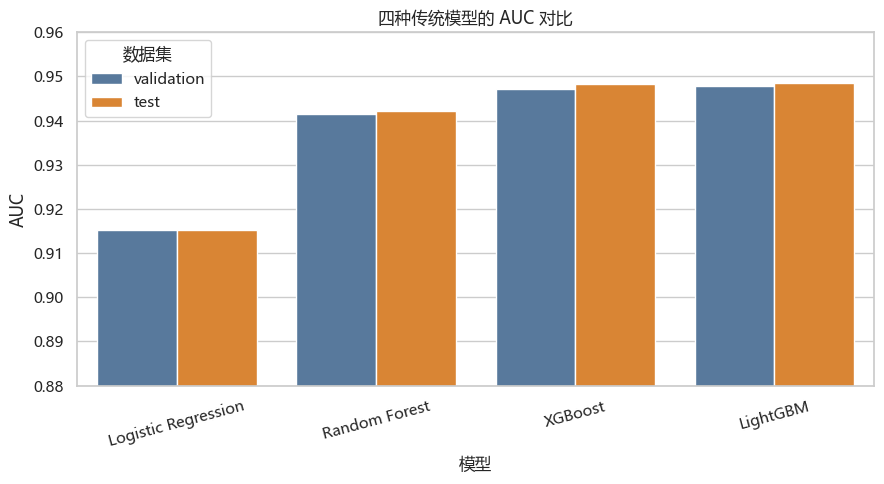

In [53]:
# 绘制四个传统模型在验证集和测试集上的 AUC 对比图。
plot_data = optuna_model_metrics[
    optuna_model_metrics["dataset"].isin(["validation", "test"])
].copy()

plt.figure(figsize=(9, 5))
sns.barplot(
    data=plot_data,
    x="model",
    y="auc",
    hue="dataset",
    palette=["#4C78A8", "#F58518"],
)
plt.ylim(0.88, 0.96)
plt.title("四种传统模型的 AUC 对比")
plt.xlabel("模型")
plt.ylabel("AUC")
plt.legend(title="数据集")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(AUC_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()


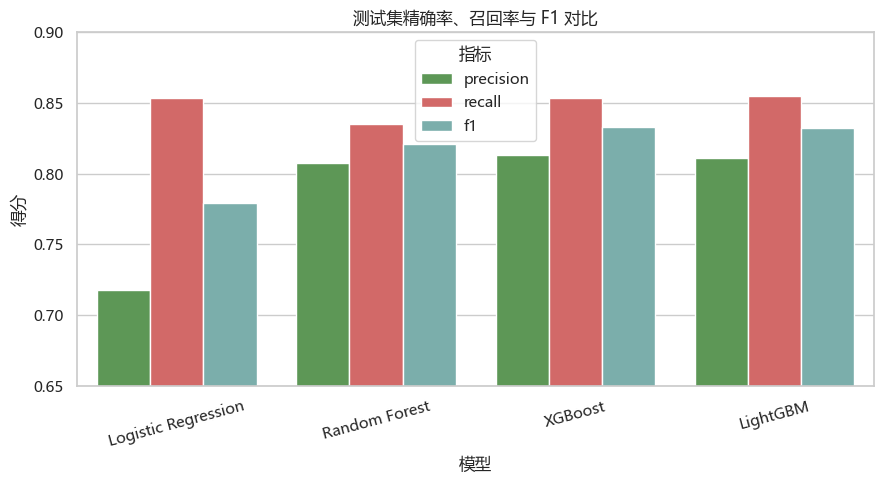

In [54]:
# 将 Precision、Recall 和 F1 转成长表，便于绘制多指标柱状图。
test_long = test_metrics.melt(
    id_vars=["model"],
    value_vars=["precision", "recall", "f1"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=test_long,
    x="model",
    y="score",
    hue="metric",
    palette=["#54A24B", "#E45756", "#72B7B2"],
)
plt.ylim(0.65, 0.9)
plt.title("测试集精确率、召回率与 F1 对比")
plt.xlabel("模型")
plt.ylabel("得分")
plt.legend(title="指标")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(METRICS_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()


In [55]:
# 用文字表总结四个传统模型的优缺点和适用场景。
model_analysis = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "advantage_scenario": "结构简单、训练速度快、结果稳定且可解释性强，适合作为二分类基线模型，并用于判断特征与取消概率的大致方向。",
            "attention_note": "主要刻画线性关系，对复杂非线性模式和特征交互表达能力有限；在本项目中 AUC、Precision 和 F1 均低于树模型，误判正常订单的比例更高。",
        },
        {
            "model": "Random Forest",
            "advantage_scenario": "通过多棵决策树投票捕捉非线性关系，对特征尺度不敏感，稳定性较好，整体性能明显优于逻辑回归。",
            "attention_note": "模型体积较大，训练和推理成本较高；虽然有效，但在本项目中的测试集 AUC 和 F1 低于 XGBoost、LightGBM。",
        },
        {
            "model": "XGBoost",
            "advantage_scenario": "适合结构化表格数据，能够逐轮修正前序模型错误，捕捉非线性和特征交互，测试集 AUC 与 F1 接近 LightGBM。",
            "attention_note": "参数较多，调参成本较高，训练速度通常慢于 LightGBM；作为多棵树叠加模型，可解释性弱于逻辑回归，也存在过拟合风险。",
        },
        {
            "model": "LightGBM",
            "advantage_scenario": "预测性能强，测试集 AUC 最高，训练和推理效率较好，适合较大规模结构化表格数据，并可输出特征重要性辅助解释。",
            "attention_note": "可解释性弱于逻辑回归，参数较多；leaf-wise 生长方式拟合能力强，如果约束不足容易过拟合，同时对数据泄露较敏感。",
        },
    ]
)

model_analysis = model_analysis.merge(
    performance_summary[
        ["model", "auc_rank", "test_auc", "test_precision", "test_recall", "test_f1"]
    ],
    on="model",
    how="left",
).sort_values("auc_rank")

performance_summary.to_csv(
    PERFORMANCE_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)
model_analysis.to_csv(
    MODEL_ANALYSIS_PATH,
    index=False,
    encoding="utf-8-sig",
)

model_analysis


,model,advantage_scenario,attention_note,auc_rank,test_auc,test_precision,test_recall,test_f1
3,LightGBM,预测性能强，测试集 AUC 最高，训练和推理效率较好，适合较大规模结构化表格数据，并可输出特...,可解释性弱于逻辑回归，参数较多；leaf-wise 生长方式拟合能力强，如果约束不足容易过拟...,1,0.9485,0.8113,0.8552,0.8326
2,XGBoost,适合结构化表格数据，能够逐轮修正前序模型错误，捕捉非线性和特征交互，测试集 AUC 与 F1...,参数较多，调参成本较高，训练速度通常慢于 LightGBM；作为多棵树叠加模型，可解释性弱于...,2,0.9483,0.8135,0.8532,0.8329
1,Random Forest,通过多棵决策树投票捕捉非线性关系，对特征尺度不敏感，稳定性较好，整体性能明显优于逻辑回归。,模型体积较大，训练和推理成本较高；虽然有效，但在本项目中的测试集 AUC 和 F1 低于 X...,3,0.9422,0.8074,0.8348,0.8209
0,Logistic Regression,结构简单、训练速度快、结果稳定且可解释性强，适合作为二分类基线模型，并用于判断特征与取消概率...,主要刻画线性关系，对复杂非线性模式和特征交互表达能力有限；在本项目中 AUC、Precisi...,4,0.9152,0.7175,0.8532,0.7795


### 2.5 不同酒店类型模型表现评估


In [56]:
# 复用 Optuna 最优参数，评估不同酒店类型下的模型表现。
def params_for_model(best_params: pd.DataFrame, model_name: str) -> dict:
    """读取指定模型的 Optuna 最优参数。"""
    model_params = best_params[best_params["model"] == model_name]
    params = {}
    for _, row in model_params.iterrows():
        value = row["value"]
        if isinstance(value, str):
            try:
                value = int(value)
            except ValueError:
                try:
                    value = float(value)
                except ValueError:
                    pass
        params[row["parameter"]] = value
    return params


def build_best_model(model_name: str, params: dict):
    """根据保存的最优参数构建传统机器学习模型。"""
    if model_name == "Logistic Regression":
        return LogisticRegression(
            penalty=params.get("penalty", "l2"),
            C=float(params.get("C", 1.0)),
            solver="liblinear",
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    if model_name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=int(params.get("n_estimators", 160)),
            max_depth=int(params.get("max_depth", 14)),
            min_samples_leaf=int(params.get("min_samples_leaf", 30)),
            min_samples_split=int(params.get("min_samples_split", 10)),
            max_features=params.get("max_features", "sqrt"),
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    if model_name == "XGBoost":
        return XGBClassifier(
            n_estimators=int(params.get("n_estimators", 180)),
            max_depth=int(params.get("max_depth", 5)),
            learning_rate=float(params.get("learning_rate", 0.08)),
            subsample=float(params.get("subsample", 0.9)),
            colsample_bytree=float(params.get("colsample_bytree", 0.9)),
            min_child_weight=float(params.get("min_child_weight", 1.0)),
            gamma=float(params.get("gamma", 0.0)),
            reg_alpha=float(params.get("reg_alpha", 0.0)),
            reg_lambda=float(params.get("reg_lambda", 1.0)),
            objective="binary:logistic",
            eval_metric="auc",
            tree_method="hist",
            scale_pos_weight=scale_pos_weight,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    if model_name == "LightGBM":
        return LGBMClassifier(
            n_estimators=int(params.get("n_estimators", 180)),
            num_leaves=int(params.get("num_leaves", 31)),
            max_depth=int(params.get("max_depth", -1)),
            learning_rate=float(params.get("learning_rate", 0.08)),
            subsample=float(params.get("subsample", 0.9)),
            colsample_bytree=float(params.get("colsample_bytree", 0.9)),
            min_child_samples=int(params.get("min_child_samples", 20)),
            reg_alpha=float(params.get("reg_alpha", 0.0)),
            reg_lambda=float(params.get("reg_lambda", 1.0)),
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
            verbose=-1,
        )
    raise ValueError(f"未知模型：{model_name}")


def evaluate_by_hotel_type(model_name: str, model) -> list[dict]:
    """分别评估模型在城市酒店与度假酒店测试样本上的表现。"""
    records = []
    for hotel_type, hotel_column in HOTEL_TYPE_COLUMNS.items():
        subset_mask = X_test[hotel_column] == 1
        metrics = evaluate_model(
            model,
            X_test.loc[subset_mask],
            y_test.loc[subset_mask],
            "test",
        )
        metrics["model"] = model_name
        metrics["hotel_type"] = hotel_type
        metrics["sample_count"] = int(subset_mask.sum())
        records.append(metrics)
    return records


if RUN_HOTEL_TYPE_EVALUATION:
    best_params = pd.read_csv(OPTUNA_BEST_PARAMS_PATH)
    hotel_type_metric_records = []

    for model_name in ["Logistic Regression", "Random Forest", "XGBoost", "LightGBM"]:
        model = build_best_model(model_name, params_for_model(best_params, model_name))
        model.fit(X_train, y_train)
        hotel_type_metric_records.extend(evaluate_by_hotel_type(model_name, model))

    hotel_type_model_metrics = pd.DataFrame(hotel_type_metric_records)
    hotel_type_model_metrics.to_csv(
        HOTEL_TYPE_MODEL_METRICS_PATH,
        index=False,
        encoding="utf-8-sig",
    )
else:
    hotel_type_model_metrics = pd.read_csv(HOTEL_TYPE_MODEL_METRICS_PATH)

hotel_type_model_metrics[
    [
        "model",
        "hotel_type",
        "sample_count",
        "auc",
        "accuracy",
        "precision",
        "recall",
        "f1",
    ]
]

,model,hotel_type,sample_count,auc,accuracy,precision,recall,f1
0,Logistic Regression,City Hotel,12401,0.9104,0.8051,0.7199,0.8699,0.7878
1,Logistic Regression,Resort Hotel,5467,0.9225,0.8526,0.7087,0.7964,0.7500
2,Random Forest,City Hotel,12401,0.9376,0.8541,0.8167,0.8371,0.8268
3,Random Forest,Resort Hotel,5467,0.9491,0.8860,0.7771,0.8267,0.8011
4,XGBoost,City Hotel,12401,0.9437,0.8628,0.8214,0.8561,0.8384
5,XGBoost,Resort Hotel,5467,0.9555,0.8932,0.7872,0.8432,0.8142
6,LightGBM,City Hotel,12401,0.9440,0.8615,0.8157,0.8616,0.8380
7,LightGBM,Resort Hotel,5467,0.9558,0.8945,0.7961,0.8333,0.8143


## 3. 深度学习模型构建与优化


### 3.1 普通 MLP 模型


In [57]:
# 定义普通 MLP 的训练、评估和预测概率保存逻辑。
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
except ImportError as exc:
    raise ImportError(
        "当前环境缺少 TensorFlow。请先安装 requirements.txt 中的依赖，"
        "再运行深度学习模型相关单元。"
    ) from exc


tf.keras.utils.set_random_seed(RANDOM_STATE)


def replace_model_rows(output_path: Path, new_data: pd.DataFrame, model_names: list[str]) -> pd.DataFrame:
    """用当前模型的新结果替换旧结果，避免重复运行 notebook 后产生重复行。"""
    new_data = new_data.copy()
    if output_path.exists():
        previous_data = pd.read_csv(output_path)
        if "model" in previous_data.columns:
            previous_data = previous_data[~previous_data["model"].isin(model_names)]
        return pd.concat([previous_data, new_data], ignore_index=True)
    return new_data


def evaluate_probability_predictions(
    y_true: pd.Series,
    positive_probability: np.ndarray,
    model_name: str,
    dataset_name: str,
) -> dict:
    """根据模型输出的取消概率计算二分类评估指标。"""
    y_pred = (positive_probability >= 0.5).astype(int)
    return {
        "model": model_name,
        "dataset": dataset_name,
        "auc": round(roc_auc_score(y_true, positive_probability), 4),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
    }


def build_training_history_records(
    history,
    model_name: str,
    config_id: int,
    config: dict,
    extra_config: dict | None = None,
) -> list[dict]:
    """把 Keras history 转换为逐 epoch 训练曲线记录。"""
    records = []
    extra_config = extra_config or {}
    epoch_count = len(history.history.get("loss", []))
    for epoch_index in range(epoch_count):
        record = {
            "model": model_name,
            "config_id": config_id,
            "epoch": epoch_index + 1,
            "loss": history.history.get("loss", [np.nan] * epoch_count)[epoch_index],
            "auc": history.history.get("auc", [np.nan] * epoch_count)[epoch_index],
            "val_loss": history.history.get("val_loss", [np.nan] * epoch_count)[epoch_index],
            "val_auc": history.history.get("val_auc", [np.nan] * epoch_count)[epoch_index],
            "hidden_units": str(config.get("hidden_units")),
            "dropout_rate": config.get("dropout_rate"),
            "learning_rate": config.get("learning_rate"),
            "batch_size": config.get("batch_size"),
            "epochs_planned": config.get("epochs"),
        }
        record.update(extra_config)
        records.append(record)
    return records


def build_mlp_model(
    input_dim: int,
    hidden_units: tuple[int, int],
    dropout_rate: float,
    learning_rate: float,
) -> keras.Model:
    """构建用于结构化特征二分类的普通 MLP 模型。"""
    model = keras.Sequential(
        [
            layers.Input(shape=(input_dim,)),
            layers.Dense(hidden_units[0]),
            layers.LeakyReLU(negative_slope=0.01),
            layers.BatchNormalization(),
            layers.Dropout(dropout_rate),
            layers.Dense(hidden_units[1]),
            layers.LeakyReLU(negative_slope=0.01),
            layers.BatchNormalization(),
            layers.Dropout(dropout_rate),
            layers.Dense(1, activation="sigmoid"),
        ]
    )
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")],
    )
    return model


def fit_mlp_model(config: dict) -> tuple[keras.Model, keras.callbacks.History, float]:
    """按给定参数训练普通 MLP，并返回训练耗时。"""
    model = build_mlp_model(
        input_dim=X_train.shape[1],
        hidden_units=config["hidden_units"],
        dropout_rate=config["dropout_rate"],
        learning_rate=config["learning_rate"],
    )
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=5,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-5,
        ),
    ]
    start_time = perf_counter()
    history = model.fit(
        X_train.astype("float32"),
        y_train.astype("int8"),
        validation_data=(X_validation.astype("float32"), y_validation.astype("int8")),
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        class_weight=class_weight_map,
        callbacks=callbacks,
        verbose=0,
    )
    elapsed_seconds = perf_counter() - start_time
    return model, history, elapsed_seconds


classes = np.array([0, 1])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)
class_weight_map = {
    int(class_label): float(weight)
    for class_label, weight in zip(classes, class_weights)
}

mlp_configs = [
    {"model": "MLP", "hidden_units": (128, 64), "dropout_rate": 0.2, "learning_rate": 0.001, "batch_size": 512, "epochs": 40},
    {"model": "MLP", "hidden_units": (256, 128), "dropout_rate": 0.3, "learning_rate": 0.001, "batch_size": 512, "epochs": 40},
    {"model": "MLP", "hidden_units": (256, 128), "dropout_rate": 0.4, "learning_rate": 0.0005, "batch_size": 512, "epochs": 50},
    {"model": "MLP", "hidden_units": (128, 64), "dropout_rate": 0.3, "learning_rate": 0.0005, "batch_size": 256, "epochs": 50},
]

if RUN_DEEP_LEARNING_TRAINING:
    mlp_tuning_records = []
    mlp_metric_records = []
    mlp_training_history_records = []
    best_mlp_model = None
    best_mlp_auc = -np.inf

    for config_id, config in enumerate(mlp_configs, start=1):
        model, history, train_seconds = fit_mlp_model(config)
        validation_probability = model.predict(
            X_validation.astype("float32"),
            verbose=0,
        ).ravel()
        validation_auc = roc_auc_score(y_validation, validation_probability)
        best_epoch = int(np.argmax(history.history["val_auc"]) + 1)
        mlp_tuning_records.append(
            {
                "model": "MLP",
                "config_id": config_id,
                "hidden_units": str(config["hidden_units"]),
                "dropout_rate": config["dropout_rate"],
                "learning_rate": config["learning_rate"],
                "batch_size": config["batch_size"],
                "epochs_planned": config["epochs"],
                "best_epoch": best_epoch,
                "best_validation_auc": round(validation_auc, 6),
                "train_seconds": round(train_seconds, 2),
            }
        )
        mlp_training_history_records.extend(
            build_training_history_records(history, "MLP", config_id, config)
        )
        if validation_auc > best_mlp_auc:
            best_mlp_auc = validation_auc
            best_mlp_model = model

    mlp_prediction_frames = []
    for dataset_name, x_data, y_data in [
        ("validation", X_validation, y_validation),
        ("test", X_test, y_test),
    ]:
        probability = best_mlp_model.predict(x_data.astype("float32"), verbose=0).ravel()
        mlp_metric_records.append(
            evaluate_probability_predictions(y_data, probability, "MLP", dataset_name)
        )
        mlp_prediction_frames.append(
            pd.DataFrame(
                {
                    "dataset": dataset_name,
                    "row_number": np.arange(len(probability)),
                    "mlp_probability": probability,
                    TARGET_COLUMN: y_data.to_numpy(),
                }
            )
        )

    mlp_tuning_results = pd.DataFrame(mlp_tuning_records)
    mlp_model_metrics = pd.DataFrame(mlp_metric_records)
    mlp_training_history = pd.DataFrame(mlp_training_history_records)
    pd.concat(mlp_prediction_frames, ignore_index=True).to_csv(
        MLP_PREDICTION_PATH,
        index=False,
        encoding="utf-8-sig",
    )

    mlp_tuning_results = replace_model_rows(
        DEEP_LEARNING_TUNING_PATH,
        mlp_tuning_results,
        ["MLP"],
    )
    mlp_model_metrics = replace_model_rows(
        DEEP_LEARNING_METRICS_PATH,
        mlp_model_metrics,
        ["MLP"],
    )
    mlp_training_history = replace_model_rows(
        DEEP_LEARNING_HISTORY_PATH,
        mlp_training_history,
        ["MLP"],
    )

    mlp_tuning_results.to_csv(DEEP_LEARNING_TUNING_PATH, index=False, encoding="utf-8-sig")
    mlp_model_metrics.to_csv(DEEP_LEARNING_METRICS_PATH, index=False, encoding="utf-8-sig")
    mlp_training_history.to_csv(DEEP_LEARNING_HISTORY_PATH, index=False, encoding="utf-8-sig")
else:
    if DEEP_LEARNING_METRICS_PATH.exists():
        mlp_model_metrics = pd.read_csv(DEEP_LEARNING_METRICS_PATH)
        mlp_tuning_results = pd.read_csv(DEEP_LEARNING_TUNING_PATH)
        if DEEP_LEARNING_HISTORY_PATH.exists():
            deep_learning_training_history = pd.read_csv(DEEP_LEARNING_HISTORY_PATH)
    else:
        print("深度学习训练默认关闭。需要运行时请将 RUN_DEEP_LEARNING_TRAINING 改为 True。")

if "mlp_tuning_results" in globals():
    display(mlp_tuning_results)
if "mlp_model_metrics" in globals():
    display(mlp_model_metrics)


,model,config_id,hidden_units,dropout_rate,learning_rate,batch_size,epochs_planned,best_epoch,best_validation_auc,train_seconds,embedding_dim
0,MLP,1,"(128, 64)",0.2,0.0010,512,40,23,0.938693,31.58,NaN
1,MLP,2,"(256, 128)",0.3,0.0010,512,40,14,0.938741,27.97,NaN
2,MLP,3,"(256, 128)",0.4,0.0005,512,50,25,0.939960,45.69,NaN
3,MLP,4,"(128, 64)",0.3,0.0005,256,50,14,0.935605,30.46,NaN
4,Embedding MLP,1,"(128, 64)",0.2,0.0010,512,40,28,0.943144,41.40,4.0
5,Embedding MLP,2,"(128, 64)",0.3,0.0010,512,40,38,0.944652,51.65,8.0
6,Embedding MLP,3,"(256, 128)",0.3,0.0005,512,50,50,0.944002,81.35,8.0
7,Embedding MLP,4,"(256, 128)",0.4,0.0005,512,50,24,0.943399,53.29,16.0


,model,dataset,auc,accuracy,precision,recall,f1
0,MLP,validation,0.9400,0.8472,0.7539,0.8745,0.8097
1,MLP,test,0.9341,0.8459,0.7648,0.8486,0.8045
2,Embedding MLP,validation,0.9447,0.8650,0.7973,0.8538,0.8246
3,Embedding MLP,test,0.9429,0.8615,0.7904,0.8567,0.8222


### 3.2 Embedding MLP 模型


In [58]:
# 构造带类别嵌入的 MLP 输入，保留高维类别字段的低维表示能力。
TRAIN_END_DATE = pd.Timestamp("2024-09-01")
VALIDATION_END_DATE = pd.Timestamp("2024-11-01")
TEST_END_DATE = pd.Timestamp("2025-01-01")

EMBEDDING_CATEGORICAL_COLUMNS = [
    "hotel",
    "meal",
    "country",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",
    "agent",
    "customer_type",
    "season_type",
    "lead_time_group",
    "special_request_group",
]

if "replace_model_rows" not in globals():
    def replace_model_rows(output_path: Path, new_data: pd.DataFrame, model_names: list[str]) -> pd.DataFrame:
        """用当前模型的新结果替换旧结果，避免重复运行 notebook 后产生重复行。"""
        new_data = new_data.copy()
        if output_path.exists():
            previous_data = pd.read_csv(output_path)
            if "model" in previous_data.columns:
                previous_data = previous_data[~previous_data["model"].isin(model_names)]
            return pd.concat([previous_data, new_data], ignore_index=True)
        return new_data


EMBEDDING_NUMERIC_COLUMNS = [
    "lead_time",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies",
    "is_repeated_guest",
    "previous_cancellations",
    "previous_bookings_not_canceled",
    "booking_changes",
    "days_in_waiting_list",
    "adr",
    "required_car_parking_spaces",
    "total_of_special_requests",
    "total_stays",
    "arrival_month_num",
    "arrival_day_of_week",
    "is_weekend",
    "is_holiday_proxy",
    "is_near_holiday_proxy",
    "is_peak_season",
    "is_low_season",
    "total_guests",
    "has_children_or_babies",
    "room_type_matched",
    "has_booking_changes",
    "has_special_requests",
    "has_car_parking_request",
    "estimated_revenue",
    "rfm_value_score",
]


def split_feature_data_by_time(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """按第二阶段一致的 arrival_date 时间窗口拆分特征工程数据。"""
    arrival_date = pd.to_datetime(data["arrival_date"])
    train_mask = arrival_date < TRAIN_END_DATE
    validation_mask = (arrival_date >= TRAIN_END_DATE) & (arrival_date < VALIDATION_END_DATE)
    test_mask = (arrival_date >= VALIDATION_END_DATE) & (arrival_date < TEST_END_DATE)
    return data.loc[train_mask].copy(), data.loc[validation_mask].copy(), data.loc[test_mask].copy()


def fit_category_mappings(train_data: pd.DataFrame, columns: list[str]) -> dict[str, dict[object, int]]:
    """仅使用训练集拟合类别到整数 ID 的映射，0 保留给未知类别。"""
    mappings = {}
    for column in columns:
        values = train_data[column].astype(str).fillna("缺失").unique().tolist()
        mappings[column] = {value: index for index, value in enumerate(values, start=1)}
    return mappings


def transform_embedding_inputs(
    data: pd.DataFrame,
    categorical_columns: list[str],
    numeric_columns: list[str],
    mappings: dict[str, dict[object, int]],
    scaler: StandardScaler,
) -> dict[str, np.ndarray]:
    """把原始类别字段和数值字段转换为 Keras 可接收的输入字典。"""
    inputs = {}
    for column in categorical_columns:
        inputs[column] = (
            data[column]
            .astype(str)
            .fillna("缺失")
            .map(mappings[column])
            .fillna(0)
            .astype("int32")
            .to_numpy()
        )
    inputs["numeric_features"] = scaler.transform(data[numeric_columns]).astype("float32")
    return inputs


def build_embedding_mlp_model(
    categorical_columns: list[str],
    categorical_cardinality: dict[str, int],
    numeric_dim: int,
    embedding_dim: int,
    hidden_units: tuple[int, int],
    dropout_rate: float,
    learning_rate: float,
) -> keras.Model:
    """构建类别 Embedding 与数值特征拼接后的 MLP 模型。"""
    inputs = []
    encoded_parts = []

    for column in categorical_columns:
        category_input = keras.Input(shape=(1,), name=column)
        category_embedding = layers.Embedding(
            input_dim=categorical_cardinality[column] + 1,
            output_dim=embedding_dim,
            name=f"{column}_embedding",
        )(category_input)
        inputs.append(category_input)
        encoded_parts.append(layers.Flatten()(category_embedding))

    numeric_input = keras.Input(shape=(numeric_dim,), name="numeric_features")
    inputs.append(numeric_input)
    encoded_parts.append(numeric_input)

    x = layers.Concatenate()(encoded_parts)
    x = layers.Dense(hidden_units[0])(x)
    x = layers.LeakyReLU(negative_slope=0.01)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(hidden_units[1])(x)
    x = layers.LeakyReLU(negative_slope=0.01)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    output = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc")],
    )
    return model


if RUN_EMBEDDING_TRAINING:
    feature_data = pd.read_parquet(FEATURE_PARQUET_PATH)
    available_categorical_columns = [
        column for column in EMBEDDING_CATEGORICAL_COLUMNS if column in feature_data.columns
    ]
    available_numeric_columns = [
        column for column in EMBEDDING_NUMERIC_COLUMNS if column in feature_data.columns
    ]

    embedding_train_df, embedding_validation_df, embedding_test_df = split_feature_data_by_time(feature_data)
    category_mappings = fit_category_mappings(embedding_train_df, available_categorical_columns)
    categorical_cardinality = {
        column: len(mapping) for column, mapping in category_mappings.items()
    }

    numeric_scaler = StandardScaler()
    numeric_scaler.fit(embedding_train_df[available_numeric_columns])

    embedding_train_inputs = transform_embedding_inputs(
        embedding_train_df,
        available_categorical_columns,
        available_numeric_columns,
        category_mappings,
        numeric_scaler,
    )
    embedding_validation_inputs = transform_embedding_inputs(
        embedding_validation_df,
        available_categorical_columns,
        available_numeric_columns,
        category_mappings,
        numeric_scaler,
    )
    embedding_test_inputs = transform_embedding_inputs(
        embedding_test_df,
        available_categorical_columns,
        available_numeric_columns,
        category_mappings,
        numeric_scaler,
    )

    embedding_y_train = embedding_train_df[TARGET_COLUMN].astype("int8")
    embedding_y_validation = embedding_validation_df[TARGET_COLUMN].astype("int8")
    embedding_y_test = embedding_test_df[TARGET_COLUMN].astype("int8")

    embedding_configs = [
        {"embedding_dim": 4, "hidden_units": (128, 64), "dropout_rate": 0.2, "learning_rate": 0.001, "batch_size": 512, "epochs": 40},
        {"embedding_dim": 8, "hidden_units": (128, 64), "dropout_rate": 0.3, "learning_rate": 0.001, "batch_size": 512, "epochs": 40},
        {"embedding_dim": 8, "hidden_units": (256, 128), "dropout_rate": 0.3, "learning_rate": 0.0005, "batch_size": 512, "epochs": 50},
        {"embedding_dim": 16, "hidden_units": (256, 128), "dropout_rate": 0.4, "learning_rate": 0.0005, "batch_size": 512, "epochs": 50},
    ]

    embedding_tuning_records = []
    embedding_metric_records = []
    embedding_training_history_records = []
    best_embedding_model = None
    best_embedding_auc = -np.inf

    for config_id, config in enumerate(embedding_configs, start=1):
        model = build_embedding_mlp_model(
            categorical_columns=available_categorical_columns,
            categorical_cardinality=categorical_cardinality,
            numeric_dim=len(available_numeric_columns),
            embedding_dim=config["embedding_dim"],
            hidden_units=config["hidden_units"],
            dropout_rate=config["dropout_rate"],
            learning_rate=config["learning_rate"],
        )
        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_auc",
                mode="max",
                patience=5,
                restore_best_weights=True,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=3,
                min_lr=1e-5,
            ),
        ]
        start_time = perf_counter()
        history = model.fit(
            embedding_train_inputs,
            embedding_y_train,
            validation_data=(embedding_validation_inputs, embedding_y_validation),
            epochs=config["epochs"],
            batch_size=config["batch_size"],
            class_weight=class_weight_map,
            callbacks=callbacks,
            verbose=0,
        )
        train_seconds = perf_counter() - start_time
        validation_probability = model.predict(embedding_validation_inputs, verbose=0).ravel()
        validation_auc = roc_auc_score(embedding_y_validation, validation_probability)
        best_epoch = int(np.argmax(history.history["val_auc"]) + 1)
        embedding_tuning_records.append(
            {
                "model": "Embedding MLP",
                "config_id": config_id,
                "embedding_dim": config["embedding_dim"],
                "hidden_units": str(config["hidden_units"]),
                "dropout_rate": config["dropout_rate"],
                "learning_rate": config["learning_rate"],
                "batch_size": config["batch_size"],
                "epochs_planned": config["epochs"],
                "best_epoch": best_epoch,
                "best_validation_auc": round(validation_auc, 6),
                "train_seconds": round(train_seconds, 2),
            }
        )
        embedding_training_history_records.extend(
            build_training_history_records(
                history,
                "Embedding MLP",
                config_id,
                config,
                extra_config={"embedding_dim": config["embedding_dim"]},
            )
        )
        if validation_auc > best_embedding_auc:
            best_embedding_auc = validation_auc
            best_embedding_model = model

    for dataset_name, input_data, y_data in [
        ("validation", embedding_validation_inputs, embedding_y_validation),
        ("test", embedding_test_inputs, embedding_y_test),
    ]:
        probability = best_embedding_model.predict(input_data, verbose=0).ravel()
        embedding_metric_records.append(
            evaluate_probability_predictions(y_data, probability, "Embedding MLP", dataset_name)
        )

    embedding_tuning_results = pd.DataFrame(embedding_tuning_records)
    embedding_model_metrics = pd.DataFrame(embedding_metric_records)
    embedding_training_history = pd.DataFrame(embedding_training_history_records)

    deep_learning_tuning_results = replace_model_rows(
        DEEP_LEARNING_TUNING_PATH,
        embedding_tuning_results,
        ["Embedding MLP"],
    )
    deep_learning_model_metrics = replace_model_rows(
        DEEP_LEARNING_METRICS_PATH,
        embedding_model_metrics,
        ["Embedding MLP"],
    )
    deep_learning_training_history = replace_model_rows(
        DEEP_LEARNING_HISTORY_PATH,
        embedding_training_history,
        ["Embedding MLP"],
    )

    deep_learning_tuning_results.to_csv(
        DEEP_LEARNING_TUNING_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    deep_learning_model_metrics.to_csv(
        DEEP_LEARNING_METRICS_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    deep_learning_training_history.to_csv(
        DEEP_LEARNING_HISTORY_PATH,
        index=False,
        encoding="utf-8-sig",
    )
else:
    if DEEP_LEARNING_METRICS_PATH.exists():
        deep_learning_model_metrics = pd.read_csv(DEEP_LEARNING_METRICS_PATH)
        if DEEP_LEARNING_HISTORY_PATH.exists():
            deep_learning_training_history = pd.read_csv(DEEP_LEARNING_HISTORY_PATH)
    else:
        print("Embedding MLP 训练默认关闭。需要运行时请将 RUN_EMBEDDING_TRAINING 改为 True。")

if "embedding_tuning_results" in globals():
    display(embedding_tuning_results)
if "deep_learning_model_metrics" in globals():
    display(deep_learning_model_metrics)


,model,config_id,embedding_dim,hidden_units,dropout_rate,learning_rate,batch_size,epochs_planned,best_epoch,best_validation_auc,train_seconds
0,Embedding MLP,1,4,"(128, 64)",0.2,0.0010,512,40,28,0.943144,43.16
1,Embedding MLP,2,8,"(128, 64)",0.3,0.0010,512,40,38,0.944652,55.91
2,Embedding MLP,3,8,"(256, 128)",0.3,0.0005,512,50,50,0.944002,83.71
3,Embedding MLP,4,16,"(256, 128)",0.4,0.0005,512,50,24,0.943399,53.77


,model,dataset,auc,accuracy,precision,recall,f1
0,MLP,validation,0.9400,0.8472,0.7539,0.8745,0.8097
1,MLP,test,0.9341,0.8459,0.7648,0.8486,0.8045
2,Embedding MLP,validation,0.9447,0.8650,0.7973,0.8538,0.8246
3,Embedding MLP,test,0.9429,0.8615,0.7904,0.8567,0.8222
4,Embedding MLP,validation,0.9447,0.8650,0.7973,0.8538,0.8246
5,Embedding MLP,test,0.9429,0.8615,0.7904,0.8567,0.8222


### 3.3 深度学习训练曲线与早停效果分析


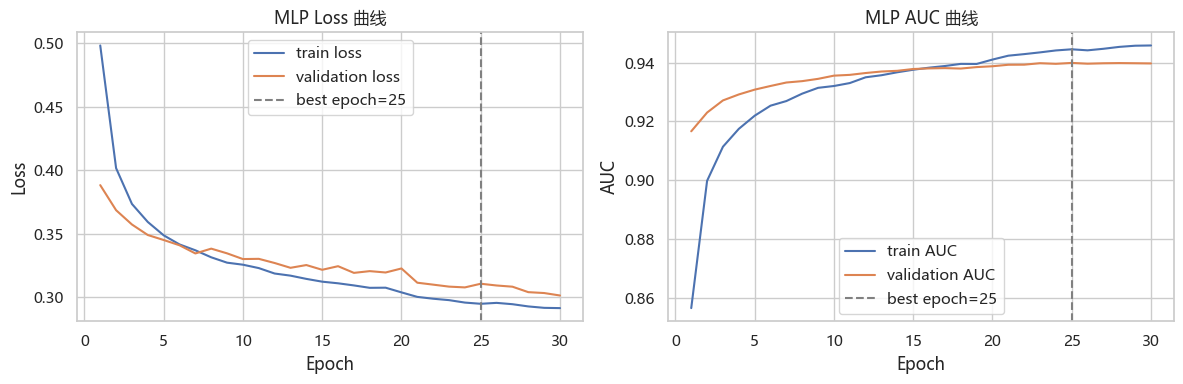

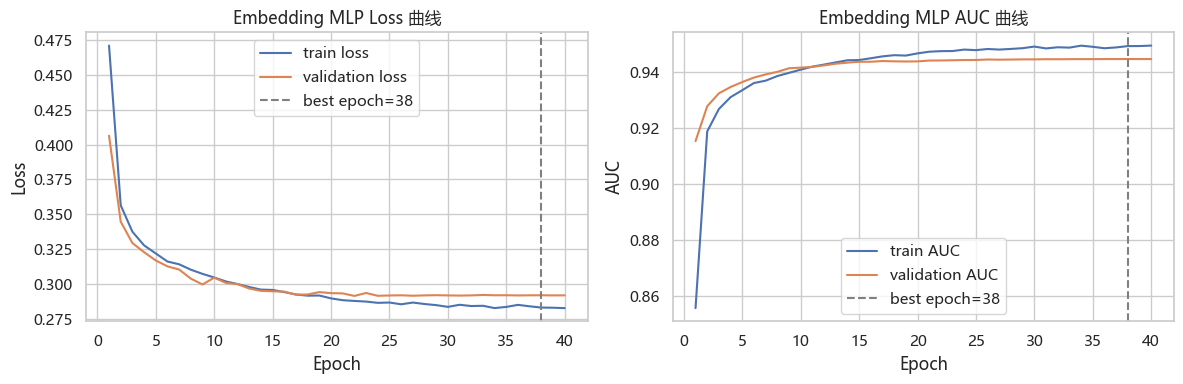

,model,best_epoch,last_epoch,best_val_auc,last_val_auc,last_train_auc,train_validation_auc_gap,early_stopping_effect
0,MLP,25,30,0.939882,0.939709,0.945806,0.006097,验证集 AUC 在最佳轮次后趋于稳定或略有回落，早停能够保留验证集表现较好的权重。
1,Embedding MLP,38,40,0.944563,0.944556,0.949352,0.004796,验证集 AUC 在最佳轮次后趋于稳定或略有回落，早停能够保留验证集表现较好的权重。


In [59]:
# 读取深度学习训练历史，绘制 loss/AUC 曲线，并判断早停策略是否有效。
def select_best_config_history(history_data: pd.DataFrame, tuning_data: pd.DataFrame, model_name: str) -> pd.DataFrame:
    """选择验证集 AUC 最高的配置，并返回该配置逐 epoch 的训练历史。"""
    best_row = (
        tuning_data[tuning_data["model"] == model_name]
        .sort_values("best_validation_auc", ascending=False)
        .iloc[0]
    )
    best_config_id = int(best_row["config_id"])
    return history_data[
        (history_data["model"] == model_name)
        & (history_data["config_id"] == best_config_id)
    ].sort_values("epoch")


def plot_training_curve(model_history: pd.DataFrame, model_name: str, output_path: Path) -> None:
    """绘制单个深度学习模型的 loss 和 AUC 训练曲线。"""
    if model_history.empty:
        print(f"没有找到 {model_name} 的训练历史，跳过绘图。")
        return

    best_epoch = int(model_history.loc[model_history["val_auc"].idxmax(), "epoch"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(model_history["epoch"], model_history["loss"], label="train loss")
    axes[0].plot(model_history["epoch"], model_history["val_loss"], label="validation loss")
    axes[0].axvline(best_epoch, color="gray", linestyle="--", label=f"best epoch={best_epoch}")
    axes[0].set_title(f"{model_name} Loss 曲线")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(model_history["epoch"], model_history["auc"], label="train AUC")
    axes[1].plot(model_history["epoch"], model_history["val_auc"], label="validation AUC")
    axes[1].axvline(best_epoch, color="gray", linestyle="--", label=f"best epoch={best_epoch}")
    axes[1].set_title(f"{model_name} AUC 曲线")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("AUC")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()


def summarize_early_stopping_effect(model_history: pd.DataFrame, model_name: str) -> dict:
    """根据训练曲线汇总过拟合迹象和早停效果。"""
    if model_history.empty:
        return {
            "model": model_name,
            "best_epoch": np.nan,
            "last_epoch": np.nan,
            "best_val_auc": np.nan,
            "last_val_auc": np.nan,
            "last_train_auc": np.nan,
            "train_validation_auc_gap": np.nan,
            "early_stopping_effect": "缺少训练历史，无法判断。",
        }

    best_index = model_history["val_auc"].idxmax()
    best_epoch = int(model_history.loc[best_index, "epoch"])
    last_row = model_history.iloc[-1]
    train_validation_gap = float(last_row["auc"] - last_row["val_auc"])
    best_before_last = best_epoch < int(last_row["epoch"])

    if best_before_last and train_validation_gap > 0.02:
        conclusion = "验证集 AUC 在最佳轮次后未继续提升，且训练集与验证集 AUC 存在差距，早停有助于降低继续训练带来的过拟合风险。"
    elif best_before_last:
        conclusion = "验证集 AUC 在最佳轮次后趋于稳定或略有回落，早停能够保留验证集表现较好的权重。"
    else:
        conclusion = "最佳轮次接近最后一轮，当前曲线没有明显显示早停触发前的过拟合扩大。"

    return {
        "model": model_name,
        "best_epoch": best_epoch,
        "last_epoch": int(last_row["epoch"]),
        "best_val_auc": round(float(model_history.loc[best_index, "val_auc"]), 6),
        "last_val_auc": round(float(last_row["val_auc"]), 6),
        "last_train_auc": round(float(last_row["auc"]), 6),
        "train_validation_auc_gap": round(train_validation_gap, 6),
        "early_stopping_effect": conclusion,
    }


if DEEP_LEARNING_HISTORY_PATH.exists() and DEEP_LEARNING_TUNING_PATH.exists():
    deep_learning_training_history = pd.read_csv(DEEP_LEARNING_HISTORY_PATH)
    deep_learning_tuning_results = pd.read_csv(DEEP_LEARNING_TUNING_PATH)

    mlp_best_history = select_best_config_history(
        deep_learning_training_history,
        deep_learning_tuning_results,
        "MLP",
    )
    embedding_best_history = select_best_config_history(
        deep_learning_training_history,
        deep_learning_tuning_results,
        "Embedding MLP",
    )

    plot_training_curve(mlp_best_history, "MLP", MLP_TRAINING_CURVE_PATH)
    plot_training_curve(
        embedding_best_history,
        "Embedding MLP",
        EMBEDDING_MLP_TRAINING_CURVE_PATH,
    )

    early_stopping_summary = pd.DataFrame(
        [
            summarize_early_stopping_effect(mlp_best_history, "MLP"),
            summarize_early_stopping_effect(embedding_best_history, "Embedding MLP"),
        ]
    )
    display(early_stopping_summary)
else:
    print(
        "当前还没有保存逐 epoch 的深度学习训练历史。"
        "如需生成 loss/AUC 曲线，请将 RUN_DEEP_LEARNING_TRAINING 和 RUN_EMBEDDING_TRAINING 改为 True，"
        "重新运行第 3.1、3.2 节后再运行本节。"
    )


### 3.4 深度学习模型与传统模型对比


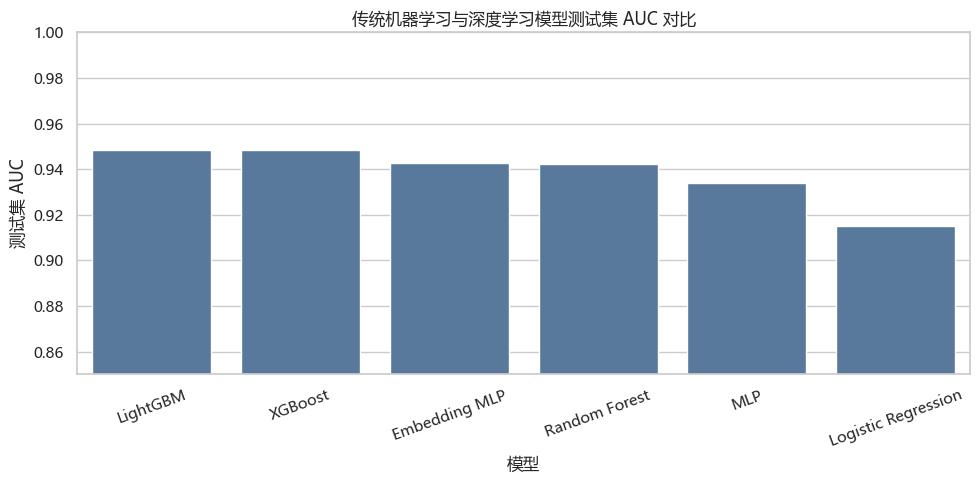

,dataset,auc,accuracy,precision,recall,f1,model,train_seconds
3,test,0.9485,0.8716,0.8113,0.8552,0.8326,LightGBM,11.26
2,test,0.9483,0.8721,0.8135,0.8532,0.8329,XGBoost,36.98
5,test,0.9429,0.8615,0.7904,0.8567,0.8222,Embedding MLP,55.91
6,test,0.9429,0.8615,0.7904,0.8567,0.8222,Embedding MLP,55.91
1,test,0.9422,0.8639,0.8074,0.8348,0.8209,Random Forest,82.59
4,test,0.9341,0.8459,0.7648,0.8486,0.8045,MLP,45.69
0,test,0.9152,0.8196,0.7175,0.8532,0.7795,Logistic Regression,48.24


In [60]:
# 汇总传统模型、普通 MLP 和 Embedding MLP 的测试集表现。
def attach_deep_learning_train_seconds(
    comparison_data: pd.DataFrame,
    tuning_path: Path = DEEP_LEARNING_TUNING_PATH,
) -> pd.DataFrame:
    """把深度学习最优配置的训练时间合并到模型对比表。"""
    if not tuning_path.exists():
        return comparison_data

    tuning_results = pd.read_csv(tuning_path)
    tuning_results = tuning_results.drop_duplicates(["model", "config_id"], keep="last")
    best_training_time = (
        tuning_results.sort_values("best_validation_auc", ascending=False)
        .drop_duplicates("model")
        [["model", "train_seconds"]]
    )
    output_data = comparison_data.copy()
    if "train_seconds" not in output_data.columns:
        output_data["train_seconds"] = np.nan
    output_data = output_data.merge(
        best_training_time.rename(columns={"train_seconds": "dl_train_seconds"}),
        on="model",
        how="left",
    )
    output_data["train_seconds"] = output_data["train_seconds"].fillna(
        output_data["dl_train_seconds"]
    )
    return output_data.drop(columns=["dl_train_seconds"])


if "deep_learning_model_metrics" in globals():
    traditional_test_metrics = optuna_model_metrics[
        optuna_model_metrics["dataset"] == "test"
    ].copy()
    deep_learning_test_metrics = deep_learning_model_metrics[
        deep_learning_model_metrics["dataset"] == "test"
    ].copy()
    deep_learning_test_metrics = deep_learning_test_metrics.drop_duplicates(
        ["model", "dataset"],
        keep="last",
    )
    model_comparison = pd.concat(
        [traditional_test_metrics, deep_learning_test_metrics],
        ignore_index=True,
    )
    model_comparison = attach_deep_learning_train_seconds(model_comparison)
    model_comparison = model_comparison.sort_values("auc", ascending=False)
    model_comparison.to_csv(
        DEEP_LEARNING_COMPARISON_PATH,
        index=False,
        encoding="utf-8-sig",
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=model_comparison,
        x="model",
        y="auc",
        color="#4C78A8",
    )
    plt.ylim(0.85, 1.0)
    plt.title("传统机器学习与深度学习模型测试集 AUC 对比")
    plt.xlabel("模型")
    plt.ylabel("测试集 AUC")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.savefig(DEEP_LEARNING_AUC_FIGURE_PATH, dpi=160, bbox_inches="tight")
    plt.show()

    display(model_comparison)
else:
    print("尚无深度学习模型结果。请先运行普通 MLP 或 Embedding MLP 训练。")


## 4. 模型融合与可解释性分析


### 4.1 多方案融合模型构建


In [61]:
# 扩展多种融合方案，用统一测试集指标比较融合是否带来增益。
ENSEMBLE_BASE_MODELS = [
    "Logistic Regression",
    "Random Forest",
    "XGBoost",
    "LightGBM",
]

STACKING_SCHEMES = [
    {
        "model": "Stacking_A_LR_XGB_LGBM_MLP",
        "base_models": ["XGBoost", "LightGBM", "MLP"],
        "meta_model": "Logistic Regression",
        "description": "XGBoost + LightGBM + MLP with Logistic Regression meta learner.",
    },
    {
        "model": "Stacking_B_LR_RF_LGBM_MLP",
        "base_models": ["Logistic Regression", "Random Forest", "LightGBM", "MLP"],
        "meta_model": "Logistic Regression",
        "description": "Linear model + bagging tree + boosting tree + MLP.",
    },
    {
        "model": "Stacking_C_RF_Meta",
        "base_models": ["XGBoost", "LightGBM", "MLP"],
        "meta_model": "Random Forest",
        "description": "XGBoost + LightGBM + MLP with Random Forest meta learner.",
    },
    {
        "model": "Stacking_D_LGBM_Meta",
        "base_models": ["XGBoost", "LightGBM", "MLP"],
        "meta_model": "LightGBM",
        "description": "XGBoost + LightGBM + MLP with LightGBM meta learner.",
    },
]

WEIGHTED_AVERAGE_SCHEMES = [
    {
        "model": "Weighted_Average_Equal",
        "weights": {"XGBoost": 1 / 3, "LightGBM": 1 / 3, "MLP": 1 / 3},
        "description": "Equal weighted average of XGBoost, LightGBM and MLP.",
    },
    {
        "model": "Weighted_Average_Tree_Heavy",
        "weights": {"XGBoost": 0.4, "LightGBM": 0.4, "MLP": 0.2},
        "description": "Higher weights for tree models, lower weight for MLP.",
    },
    {
        "model": "Weighted_Average_LGBM_Heavy",
        "weights": {"XGBoost": 0.25, "LightGBM": 0.55, "MLP": 0.2},
        "description": "Higher weight for LightGBM, the strongest single model.",
    },
]




In [62]:
# 定义融合实验复用的模型拟合、概率汇总、指标评估和元学习器函数。
def fit_best_traditional_models(best_params: pd.DataFrame) -> dict[str, object]:
    """Fit traditional models with saved Optuna best parameters."""
    fitted_models = {}
    for model_name in ENSEMBLE_BASE_MODELS:
        params = params_for_model(best_params, model_name)
        model = build_best_model(model_name, params)
        model.fit(X_train, y_train)
        fitted_models[model_name] = model
    return fitted_models


def predict_probability_table(
    fitted_models: dict[str, object],
    x_data: pd.DataFrame,
) -> pd.DataFrame:
    """Collect cancellation probabilities from fitted base models."""
    probability_data = {
        model_name: model.predict_proba(x_data)[:, 1]
        for model_name, model in fitted_models.items()
    }
    return pd.DataFrame(probability_data, index=x_data.index)


def load_mlp_probability(split_name: str) -> np.ndarray:
    """Load saved MLP cancellation probabilities for a given split."""
    if not MLP_PREDICTION_PATH.exists():
        raise FileNotFoundError(
            "Missing MLP prediction file. Run the MLP training cell first."
        )
    mlp_predictions = pd.read_csv(MLP_PREDICTION_PATH)
    split_predictions = mlp_predictions[
        mlp_predictions["dataset"] == split_name
    ].sort_values("row_number")
    return split_predictions["mlp_probability"].to_numpy()


def evaluate_probability_series(
    y_true: pd.Series,
    positive_probability: np.ndarray,
    model_name: str,
    dataset_name: str = "test",
    model_type: str = "single",
    description: str = "",
) -> dict:
    """Evaluate binary classification metrics from predicted probabilities."""
    y_pred = (positive_probability >= 0.5).astype(int)
    return {
        "model": model_name,
        "model_type": model_type,
        "dataset": dataset_name,
        "auc": round(roc_auc_score(y_true, positive_probability), 4),
        "accuracy": round(accuracy_score(y_true, y_pred), 4),
        "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, zero_division=0), 4),
        "f1": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "description": description,
    }


def build_meta_model(meta_model_name: str):
    """Build a second-layer meta learner for probability-level stacking."""
    if meta_model_name == "Logistic Regression":
        return LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    if meta_model_name == "Random Forest":
        return RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            min_samples_leaf=30,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    if meta_model_name == "LightGBM":
        return LGBMClassifier(
            n_estimators=120,
            num_leaves=15,
            max_depth=4,
            learning_rate=0.05,
            min_child_samples=80,
            class_weight="balanced",
            objective="binary",
            verbosity=-1,
            random_state=RANDOM_STATE,
        )
    raise ValueError(f"Unknown meta learner: {meta_model_name}")


def weighted_probability(probability_table: pd.DataFrame, weights: dict[str, float]) -> np.ndarray:
    """Calculate weighted average probability from multiple base models."""
    output = np.zeros(probability_table.shape[0])
    for model_name, weight in weights.items():
        output += probability_table[model_name].to_numpy() * weight
    return output




In [63]:
# 准备融合实验所需的基础模型预测概率。
if RUN_MODEL_FUSION_EXPLAINABILITY:
    best_params = pd.read_csv(OPTUNA_BEST_PARAMS_PATH)
    fitted_traditional_models = fit_best_traditional_models(best_params)

    validation_probability_table = predict_probability_table(
        fitted_traditional_models,
        X_validation,
    )
    test_probability_table = predict_probability_table(
        fitted_traditional_models,
        X_test,
    )
    validation_probability_table["MLP"] = load_mlp_probability("validation")
    test_probability_table["MLP"] = load_mlp_probability("test")

    ensemble_records = []
    ensemble_prediction_table = pd.DataFrame(index=test_probability_table.index)
    for model_name, probability in test_probability_table.items():
        ensemble_prediction_table[model_name] = probability.to_numpy()
        ensemble_records.append(
            evaluate_probability_series(
                y_test,
                probability.to_numpy(),
                model_name,
                model_type="single",
                description="Base single model probability.",
            )
        )
else:
    ensemble_model_metrics = pd.read_csv(ENSEMBLE_MODEL_METRICS_PATH)
    saved_model_comparison = pd.read_csv(DEEP_LEARNING_COMPARISON_PATH)


In [64]:
# 执行加权平均融合方案。
if RUN_MODEL_FUSION_EXPLAINABILITY:
    for scheme in WEIGHTED_AVERAGE_SCHEMES:
        weighted_test_probability = weighted_probability(
            test_probability_table,
            scheme["weights"],
        )
        ensemble_prediction_table[scheme["model"]] = weighted_test_probability
        ensemble_records.append(
            evaluate_probability_series(
                y_test,
                weighted_test_probability,
                scheme["model"],
                model_type="weighted_average",
                description=scheme["description"],
            )
        )


In [65]:
# Stacking A：XGBoost + LightGBM + MLP，元学习器为逻辑回归。
if RUN_MODEL_FUSION_EXPLAINABILITY:
    scheme = STACKING_SCHEMES[0]
    base_models = scheme["base_models"]
    meta_model = build_meta_model(scheme["meta_model"])
    meta_model.fit(validation_probability_table[base_models], y_validation)
    stacking_a_probability = meta_model.predict_proba(
        test_probability_table[base_models]
    )[:, 1]
    ensemble_prediction_table[scheme["model"]] = stacking_a_probability
    ensemble_records.append(
        evaluate_probability_series(
            y_test,
            stacking_a_probability,
            scheme["model"],
            model_type="stacking",
            description=scheme["description"],
        )
    )


In [66]:
# Stacking B：Logistic Regression + Random Forest + LightGBM + MLP。
if RUN_MODEL_FUSION_EXPLAINABILITY:
    scheme = STACKING_SCHEMES[1]
    base_models = scheme["base_models"]
    meta_model = build_meta_model(scheme["meta_model"])
    meta_model.fit(validation_probability_table[base_models], y_validation)
    stacking_b_probability = meta_model.predict_proba(
        test_probability_table[base_models]
    )[:, 1]
    ensemble_prediction_table[scheme["model"]] = stacking_b_probability
    ensemble_records.append(
        evaluate_probability_series(
            y_test,
            stacking_b_probability,
            scheme["model"],
            model_type="stacking",
            description=scheme["description"],
        )
    )


In [67]:
# Stacking C：XGBoost + LightGBM + MLP，元学习器为随机森林。
if RUN_MODEL_FUSION_EXPLAINABILITY:
    scheme = STACKING_SCHEMES[2]
    base_models = scheme["base_models"]
    meta_model = build_meta_model(scheme["meta_model"])
    meta_model.fit(validation_probability_table[base_models], y_validation)
    stacking_c_probability = meta_model.predict_proba(
        test_probability_table[base_models]
    )[:, 1]
    ensemble_prediction_table[scheme["model"]] = stacking_c_probability
    ensemble_records.append(
        evaluate_probability_series(
            y_test,
            stacking_c_probability,
            scheme["model"],
            model_type="stacking",
            description=scheme["description"],
        )
    )


In [68]:
# Stacking D：XGBoost + LightGBM + MLP，元学习器为 LightGBM。
if RUN_MODEL_FUSION_EXPLAINABILITY:
    scheme = STACKING_SCHEMES[3]
    base_models = scheme["base_models"]
    meta_model = build_meta_model(scheme["meta_model"])
    meta_model.fit(validation_probability_table[base_models], y_validation)
    stacking_d_probability = meta_model.predict_proba(
        test_probability_table[base_models]
    )[:, 1]
    ensemble_prediction_table[scheme["model"]] = stacking_d_probability
    ensemble_records.append(
        evaluate_probability_series(
            y_test,
            stacking_d_probability,
            scheme["model"],
            model_type="stacking",
            description=scheme["description"],
        )
    )


In [69]:
# 所有融合方案运行完后，保存评估指标和预测概率。
if RUN_MODEL_FUSION_EXPLAINABILITY:
    ensemble_model_metrics = pd.DataFrame(ensemble_records).sort_values(
        ["auc", "f1"],
        ascending=[False, False],
    )
    ensemble_model_metrics["auc_rank"] = ensemble_model_metrics["auc"].rank(
        ascending=False,
        method="dense",
    ).astype(int)
    ensemble_model_metrics.to_csv(
        ENSEMBLE_MODEL_METRICS_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    ensemble_prediction_table.to_csv(
        ENSEMBLE_MODEL_PREDICTION_PATH,
        index=False,
        encoding="utf-8-sig",
    )

    saved_model_comparison = pd.read_csv(DEEP_LEARNING_COMPARISON_PATH)


In [70]:
# 将融合模型结果与已有单模型结果合并，形成统一对比表。
fusion_model_names = ensemble_model_metrics[
    ensemble_model_metrics["model_type"].isin(["weighted_average", "stacking"])
]["model"]
ensemble_model_comparison = pd.concat(
    [
        saved_model_comparison,
        ensemble_model_metrics[ensemble_model_metrics["model"].isin(fusion_model_names)],
    ],
    ignore_index=True,
).sort_values("auc", ascending=False)
ensemble_model_comparison = attach_deep_learning_train_seconds(
    ensemble_model_comparison
)
if "model_type" not in ensemble_model_comparison.columns:
    ensemble_model_comparison["model_type"] = "single"
ensemble_model_comparison["model_type"] = ensemble_model_comparison["model_type"].fillna("single")
ensemble_model_comparison.to_csv(
    ENSEMBLE_MODEL_COMPARISON_PATH,
    index=False,
    encoding="utf-8-sig",
)



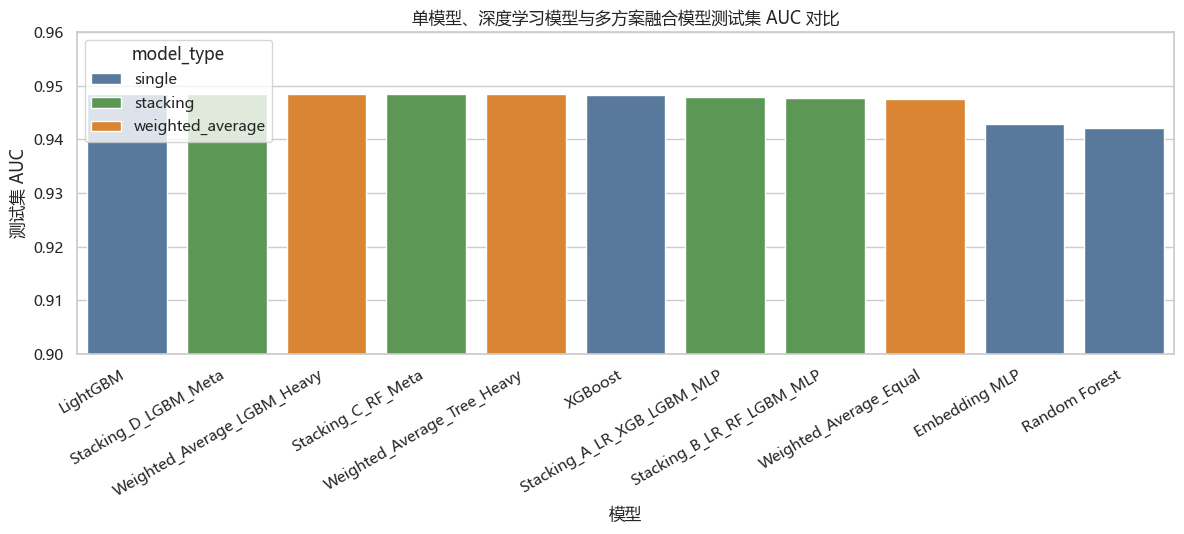

,model,model_type,dataset,auc,accuracy,precision,recall,f1,description,auc_rank
0,Stacking_D_LGBM_Meta,stacking,test,0.9485,0.8735,0.8193,0.8487,0.8337,XGBoost + LightGBM + MLP with LightGBM meta le...,1
1,Weighted_Average_LGBM_Heavy,weighted_average,test,0.9485,0.8720,0.8117,0.8561,0.8333,"Higher weight for LightGBM, the strongest sing...",1
2,LightGBM,single,test,0.9485,0.8716,0.8113,0.8552,0.8326,Base single model probability.,1
3,Stacking_C_RF_Meta,stacking,test,0.9485,0.8726,0.8176,0.8481,0.8326,XGBoost + LightGBM + MLP with Random Forest me...,1
4,Weighted_Average_Tree_Heavy,weighted_average,test,0.9484,0.8721,0.8130,0.8543,0.8331,"Higher weights for tree models, lower weight f...",2
5,XGBoost,single,test,0.9483,0.8721,0.8135,0.8532,0.8329,Base single model probability.,3
6,Stacking_A_LR_XGB_LGBM_MLP,stacking,test,0.9480,0.8713,0.8089,0.8583,0.8328,XGBoost + LightGBM + MLP with Logistic Regress...,4
7,Stacking_B_LR_RF_LGBM_MLP,stacking,test,0.9477,0.8708,0.8091,0.8562,0.8320,Linear model + bagging tree + boosting tree + ...,5
8,Weighted_Average_Equal,weighted_average,test,0.9476,0.8710,0.8097,0.8559,0.8322,"Equal weighted average of XGBoost, LightGBM an...",6
9,Random Forest,single,test,0.9422,0.8639,0.8074,0.8348,0.8209,Base single model probability.,7


,dataset,auc,accuracy,precision,recall,f1,model,train_seconds,model_type,description,auc_rank
0,test,0.9485,0.8716,0.8113,0.8552,0.8326,LightGBM,11.26,single,NaN,NaN
1,test,0.9485,0.8735,0.8193,0.8487,0.8337,Stacking_D_LGBM_Meta,NaN,stacking,XGBoost + LightGBM + MLP with LightGBM meta le...,1.0
2,test,0.9485,0.8720,0.8117,0.8561,0.8333,Weighted_Average_LGBM_Heavy,NaN,weighted_average,"Higher weight for LightGBM, the strongest sing...",1.0
3,test,0.9485,0.8726,0.8176,0.8481,0.8326,Stacking_C_RF_Meta,NaN,stacking,XGBoost + LightGBM + MLP with Random Forest me...,1.0
4,test,0.9484,0.8721,0.8130,0.8543,0.8331,Weighted_Average_Tree_Heavy,NaN,weighted_average,"Higher weights for tree models, lower weight f...",2.0
5,test,0.9483,0.8721,0.8135,0.8532,0.8329,XGBoost,36.98,single,NaN,NaN
6,test,0.9480,0.8713,0.8089,0.8583,0.8328,Stacking_A_LR_XGB_LGBM_MLP,NaN,stacking,XGBoost + LightGBM + MLP with Logistic Regress...,4.0
7,test,0.9477,0.8708,0.8091,0.8562,0.8320,Stacking_B_LR_RF_LGBM_MLP,NaN,stacking,Linear model + bagging tree + boosting tree + ...,5.0
8,test,0.9476,0.8710,0.8097,0.8559,0.8322,Weighted_Average_Equal,NaN,weighted_average,"Equal weighted average of XGBoost, LightGBM an...",6.0
9,test,0.9429,0.8615,0.7904,0.8567,0.8222,Embedding MLP,55.91,single,NaN,NaN


In [71]:
# 绘制单模型和融合方案的 AUC 对比图。
plt.figure(figsize=(12, 5.5))
sns.barplot(
    data=ensemble_model_comparison.head(12),
    x="model",
    y="auc",
    hue="model_type",
    dodge=False,
    palette={"single": "#4C78A8", "weighted_average": "#F58518", "stacking": "#54A24B"},
)
plt.ylim(0.9, 0.96)
plt.title("单模型、深度学习模型与多方案融合模型测试集 AUC 对比")
plt.xlabel("模型")
plt.ylabel("测试集 AUC")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(ENSEMBLE_MODEL_COMPARISON_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

display(ensemble_model_metrics)
display(ensemble_model_comparison)


### 4.2 模型可解释性分析


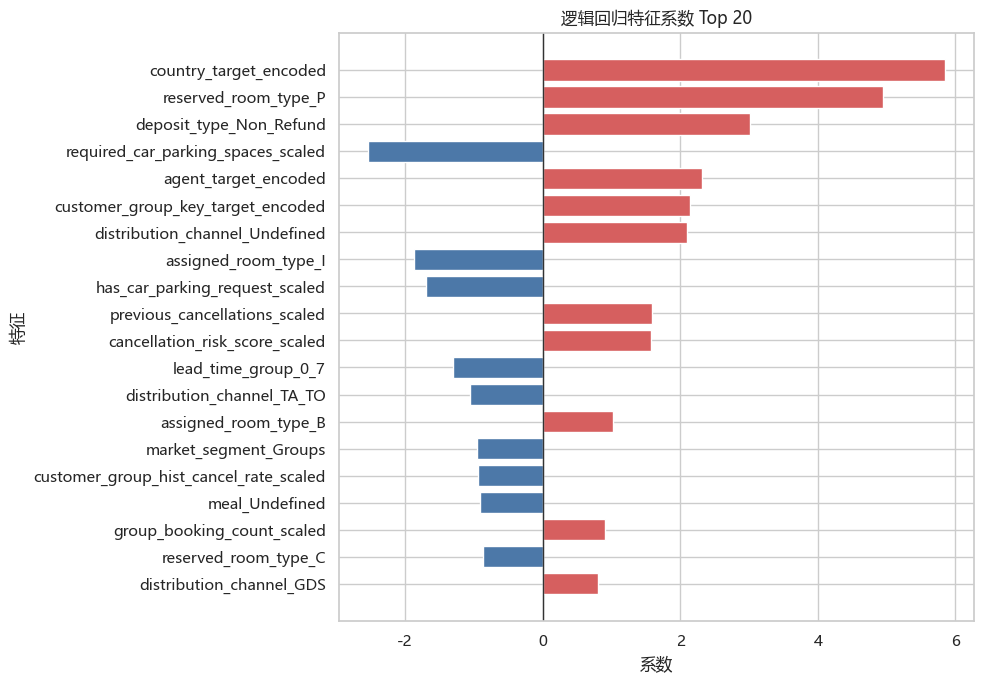

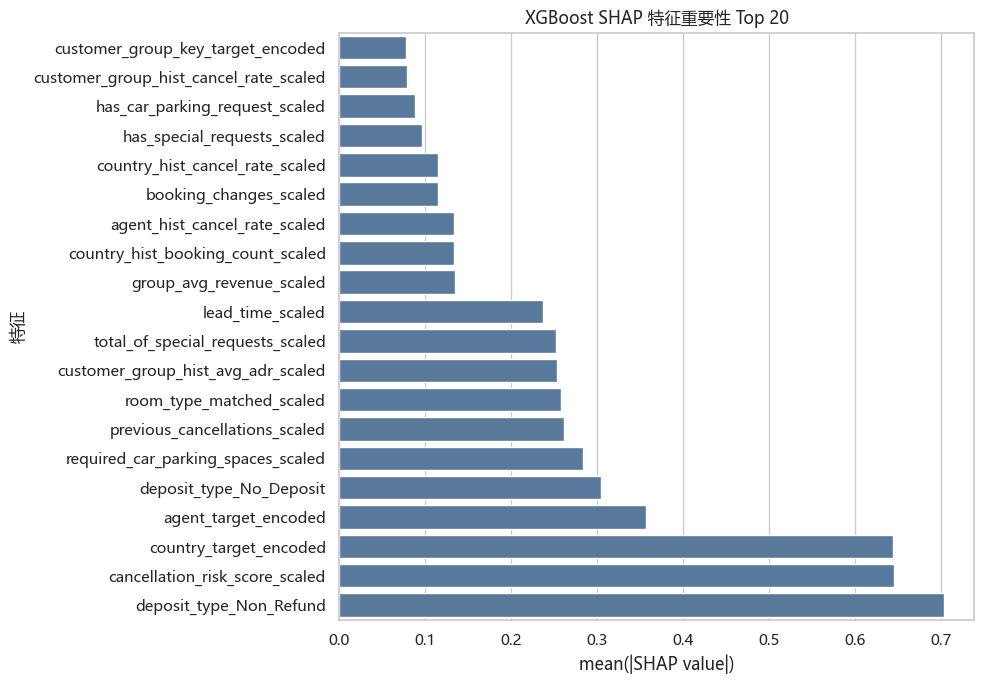

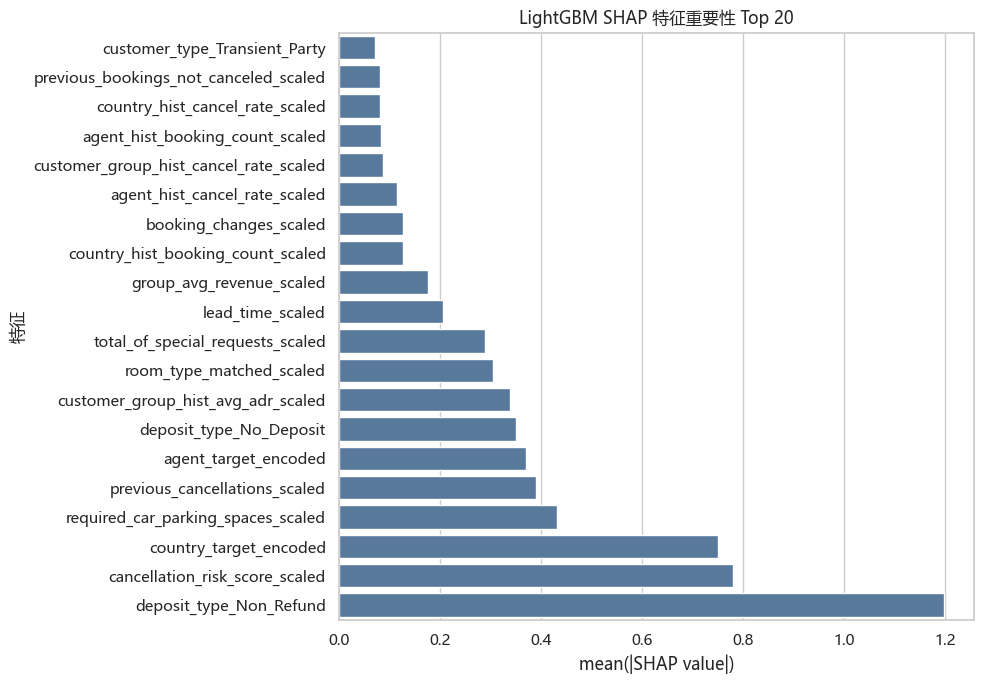

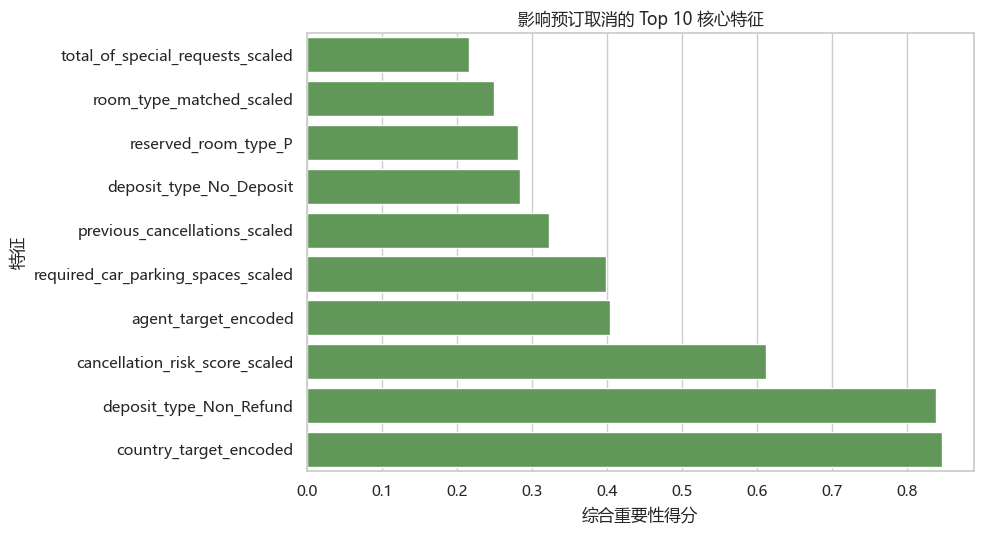

,feature_name,coefficient,abs_coefficient,direction
0,country_target_encoded,5.850066,5.850066,提高取消概率
1,reserved_room_type_P,4.942150,4.942150,提高取消概率
2,deposit_type_Non_Refund,3.020063,3.020063,提高取消概率
3,required_car_parking_spaces_scaled,-2.538052,2.538052,降低取消概率
4,agent_target_encoded,2.317066,2.317066,提高取消概率
5,customer_group_key_target_encoded,2.148130,2.148130,提高取消概率
6,distribution_channel_Undefined,2.096223,2.096223,提高取消概率
7,assigned_room_type_I,-1.872822,1.872822,降低取消概率
8,has_car_parking_request_scaled,-1.688941,1.688941,降低取消概率
9,previous_cancellations_scaled,1.589357,1.589357,提高取消概率


,model,feature_name,mean_abs_shap
0,XGBoost,deposit_type_Non_Refund,0.703299
1,XGBoost,cancellation_risk_score_scaled,0.645325
2,XGBoost,country_target_encoded,0.644205
3,XGBoost,agent_target_encoded,0.356489
4,XGBoost,deposit_type_No_Deposit,0.304595
5,XGBoost,required_car_parking_spaces_scaled,0.283261
6,XGBoost,previous_cancellations_scaled,0.261556
7,XGBoost,room_type_matched_scaled,0.257854
8,XGBoost,customer_group_hist_avg_adr_scaled,0.253742
9,XGBoost,total_of_special_requests_scaled,0.252475


,feature_name,logistic_score,xgboost_shap_score,lightgbm_shap_score,logistic_score_norm,xgboost_shap_score_norm,lightgbm_shap_score_norm,combined_score
0,country_target_encoded,5.850066,0.644205,0.749162,1.000000,0.915976,0.625836,0.847271
1,deposit_type_Non_Refund,3.020063,0.703299,1.197058,0.516244,1.000000,1.000000,0.838748
2,cancellation_risk_score_scaled,1.578427,0.645325,0.779287,0.269814,0.917569,0.651001,0.612794
3,agent_target_encoded,2.317066,0.356489,0.369100,0.396075,0.506881,0.308340,0.403765
4,required_car_parking_spaces_scaled,2.538052,0.283261,0.431437,0.433850,0.402760,0.360414,0.399008
5,previous_cancellations_scaled,1.589357,0.261556,0.388781,0.271682,0.371900,0.324780,0.322787
6,deposit_type_No_Deposit,0.733635,0.304595,0.350785,0.125406,0.433095,0.293039,0.283847
7,reserved_room_type_P,4.942150,0.000000,0.000000,0.844802,0.000000,0.000000,0.281601
8,room_type_matched_scaled,0.756719,0.257854,0.304837,0.129352,0.366635,0.254655,0.250214
9,total_of_special_requests_scaled,0.289438,0.252475,0.289652,0.049476,0.358987,0.241970,0.216811


In [72]:
# 计算逻辑回归系数和树模型 SHAP 值，用于解释核心影响特征。
def extract_shap_values(shap_explanation) -> np.ndarray:
    """从 SHAP 解释对象中提取二分类正类的 SHAP 值矩阵。"""
    values = shap_explanation.values if hasattr(shap_explanation, "values") else shap_explanation
    if isinstance(values, list):
        values = values[1]
    values = np.asarray(values)
    if values.ndim == 3:
        values = values[:, :, 1]
    return values


def build_shap_importance(model, x_sample: pd.DataFrame, model_name: str) -> pd.DataFrame:
    """计算树模型每个特征的平均绝对 SHAP 值。"""
    explainer = shap.TreeExplainer(model)
    shap_values = extract_shap_values(explainer(x_sample))
    return pd.DataFrame(
        {
            "model": model_name,
            "feature_name": x_sample.columns,
            "mean_abs_shap": np.abs(shap_values).mean(axis=0),
        }
    ).sort_values("mean_abs_shap", ascending=False)


def normalize_score(series: pd.Series) -> pd.Series:
    """将重要性分数缩放到 0-1，便于不同解释方法合并比较。"""
    max_value = series.max()
    if pd.isna(max_value) or max_value == 0:
        return series * 0
    return series / max_value


if RUN_MODEL_FUSION_EXPLAINABILITY:
    best_params = pd.read_csv(OPTUNA_BEST_PARAMS_PATH)

    logistic_model = build_best_model(
        "Logistic Regression",
        params_for_model(best_params, "Logistic Regression"),
    )
    logistic_model.fit(X_train, y_train)

    if "fitted_traditional_models" not in globals():
        fitted_traditional_models = fit_best_traditional_models(best_params)

    xgboost_model = fitted_traditional_models["XGBoost"]
    lightgbm_model = fitted_traditional_models["LightGBM"]

    logistic_coefficient_report = pd.DataFrame(
        {
            "feature_name": X_train.columns,
            "coefficient": logistic_model.coef_.ravel(),
        }
    )
    logistic_coefficient_report["abs_coefficient"] = logistic_coefficient_report[
        "coefficient"
    ].abs()
    logistic_coefficient_report["direction"] = np.where(
        logistic_coefficient_report["coefficient"] >= 0,
        "提高取消概率",
        "降低取消概率",
    )
    logistic_coefficient_report = logistic_coefficient_report.sort_values(
        "abs_coefficient",
        ascending=False,
    )
    logistic_coefficient_report.to_csv(
        LOGISTIC_COEFFICIENT_PATH,
        index=False,
        encoding="utf-8-sig",
    )

    shap_sample_size = min(2000, X_test.shape[0])
    shap_x = X_test.sample(n=shap_sample_size, random_state=RANDOM_STATE)
    shap_importance_report = pd.concat(
        [
            build_shap_importance(xgboost_model, shap_x, "XGBoost"),
            build_shap_importance(lightgbm_model, shap_x, "LightGBM"),
        ],
        ignore_index=True,
    )
    shap_importance_report.to_csv(
        SHAP_IMPORTANCE_PATH,
        index=False,
        encoding="utf-8-sig",
    )

    logistic_score = logistic_coefficient_report[
        ["feature_name", "abs_coefficient"]
    ].rename(columns={"abs_coefficient": "logistic_score"})
    xgboost_score = shap_importance_report[
        shap_importance_report["model"] == "XGBoost"
    ][["feature_name", "mean_abs_shap"]].rename(
        columns={"mean_abs_shap": "xgboost_shap_score"}
    )
    lightgbm_score = shap_importance_report[
        shap_importance_report["model"] == "LightGBM"
    ][["feature_name", "mean_abs_shap"]].rename(
        columns={"mean_abs_shap": "lightgbm_shap_score"}
    )

    core_feature_top10 = logistic_score.merge(
        xgboost_score,
        on="feature_name",
        how="outer",
    ).merge(
        lightgbm_score,
        on="feature_name",
        how="outer",
    ).fillna(0)
    for score_column in [
        "logistic_score",
        "xgboost_shap_score",
        "lightgbm_shap_score",
    ]:
        core_feature_top10[f"{score_column}_norm"] = normalize_score(
            core_feature_top10[score_column]
        )
    core_feature_top10["combined_score"] = core_feature_top10[
        [
            "logistic_score_norm",
            "xgboost_shap_score_norm",
            "lightgbm_shap_score_norm",
        ]
    ].mean(axis=1)
    core_feature_top10 = core_feature_top10.sort_values(
        "combined_score",
        ascending=False,
    ).head(10)
    core_feature_top10.to_csv(
        CORE_FEATURE_TOP10_PATH,
        index=False,
        encoding="utf-8-sig",
    )
else:
    logistic_coefficient_report = pd.read_csv(LOGISTIC_COEFFICIENT_PATH)
    shap_importance_report = pd.read_csv(SHAP_IMPORTANCE_PATH)
    core_feature_top10 = pd.read_csv(CORE_FEATURE_TOP10_PATH)

plt.figure(figsize=(10, 7))
top_logistic_coefficients = logistic_coefficient_report.head(20).sort_values(
    "abs_coefficient"
)
coefficient_colors = np.where(
    top_logistic_coefficients["coefficient"] >= 0,
    "#D65F5F",
    "#4C78A8",
)
plt.barh(
    top_logistic_coefficients["feature_name"],
    top_logistic_coefficients["coefficient"],
    color=coefficient_colors,
)
plt.axvline(0, color="#333333", linewidth=1)
plt.title("逻辑回归特征系数 Top 20")
plt.xlabel("系数")
plt.ylabel("特征")
plt.tight_layout()
plt.savefig(LOGISTIC_COEFFICIENT_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

for model_name, figure_path in [
    ("XGBoost", SHAP_XGBOOST_FIGURE_PATH),
    ("LightGBM", SHAP_LIGHTGBM_FIGURE_PATH),
]:
    plt.figure(figsize=(10, 7))
    top_shap = shap_importance_report[
        shap_importance_report["model"] == model_name
    ].head(20).sort_values("mean_abs_shap")
    sns.barplot(
        data=top_shap,
        x="mean_abs_shap",
        y="feature_name",
        color="#4C78A8",
    )
    plt.title(f"{model_name} SHAP 特征重要性 Top 20")
    plt.xlabel("mean(|SHAP value|)")
    plt.ylabel("特征")
    plt.tight_layout()
    plt.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()

plt.figure(figsize=(10, 5.5))
top_core_features = core_feature_top10.sort_values("combined_score")
sns.barplot(
    data=top_core_features,
    x="combined_score",
    y="feature_name",
    color="#59A14F",
)
plt.title("影响预订取消的 Top 10 核心特征")
plt.xlabel("综合重要性得分")
plt.ylabel("特征")
plt.tight_layout()
plt.savefig(CORE_FEATURE_TOP10_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

display(logistic_coefficient_report.head(20))
display(shap_importance_report.groupby("model").head(20))
display(core_feature_top10)


### 4.3 预测错误样本分析


In [73]:
# 基于最优融合方案的预测概率，分析模型容易出错的订单场景。
def label_prediction_error(row: pd.Series) -> str:
    """根据真实标签和预测标签划分预测正确、误判和漏判。"""
    if row["is_prediction_error"] == 0:
        return "预测正确"
    if row[TARGET_COLUMN] == 1 and row["predicted_label"] == 0:
        return "漏判：实际取消但预测未取消"
    return "误判：实际未取消但预测取消"


def decode_one_hot_category(
    data: pd.DataFrame,
    prefix: str,
    output_column: str,
) -> None:
    """从 One-Hot 字段中反推出便于分组分析的类别字段。"""
    category_columns = [col for col in data.columns if col.startswith(prefix)]
    if not category_columns:
        data[output_column] = "未提供"
        return
    decoded = data[category_columns].idxmax(axis=1).str.replace(
        prefix,
        "",
        regex=False,
    )
    decoded = decoded.str.replace("_", " ", regex=False)
    all_zero_mask = data[category_columns].sum(axis=1) == 0
    decoded.loc[all_zero_mask] = "未识别"
    data[output_column] = decoded


def positive_scaled_flag(data: pd.DataFrame, column: str) -> pd.Series:
    """将标准化后的二元字段还原成是否为正类的近似标识。"""
    if column not in data.columns:
        return pd.Series(False, index=data.index)
    return data[column] > 0


def build_error_segment_summary(
    data: pd.DataFrame,
    segment_columns: list[str],
) -> pd.DataFrame:
    """按业务字段统计各分组的预测错误率和错误类型。"""
    records = []
    for column in segment_columns:
        if column not in data.columns:
            continue
        grouped = data.groupby(column, dropna=False)
        for value, group in grouped:
            records.append(
                {
                    "segment_column": column,
                    "segment_value": value,
                    "sample_count": group.shape[0],
                    "cancel_rate": round(group[TARGET_COLUMN].mean(), 4),
                    "avg_predicted_probability": round(
                        group["predicted_probability"].mean(),
                        4,
                    ),
                    "error_count": int(group["is_prediction_error"].sum()),
                    "error_rate": round(group["is_prediction_error"].mean(), 4),
                    "false_negative_count": int(
                        (group["error_type"] == "漏判：实际取消但预测未取消").sum()
                    ),
                    "false_positive_count": int(
                        (group["error_type"] == "误判：实际未取消但预测取消").sum()
                    ),
                }
            )
    return pd.DataFrame(records).sort_values(
        ["error_rate", "sample_count"],
        ascending=[False, False],
    )


def summarize_binary_scenario(
    data: pd.DataFrame,
    scenario_column: str,
    scenario_name: str,
) -> dict:
    """统计某个二元场景下的样本量、取消率和预测错误率。"""
    scenario_data = data[data[scenario_column] == 1]
    non_scenario_data = data[data[scenario_column] == 0]
    return {
        "scenario": scenario_name,
        "scenario_count": scenario_data.shape[0],
        "scenario_cancel_rate": round(scenario_data[TARGET_COLUMN].mean(), 4),
        "scenario_error_rate": round(
            scenario_data["is_prediction_error"].mean(),
            4,
        ),
        "non_scenario_count": non_scenario_data.shape[0],
        "non_scenario_cancel_rate": round(non_scenario_data[TARGET_COLUMN].mean(), 4),
        "non_scenario_error_rate": round(
            non_scenario_data["is_prediction_error"].mean(),
            4,
        ),
        "error_rate_gap": round(
            scenario_data["is_prediction_error"].mean()
            - non_scenario_data["is_prediction_error"].mean(),
            4,
        ),
    }




In [74]:
# 生成最优融合模型的预测错误明细和分组统计结果。
if RUN_MODEL_FUSION_EXPLAINABILITY:
    if "ensemble_prediction_table" not in globals():
        if not ENSEMBLE_MODEL_PREDICTION_PATH.exists():
            raise FileNotFoundError("Missing ensemble prediction file. Run section 4.1 first.")
        ensemble_prediction_table = pd.read_csv(ENSEMBLE_MODEL_PREDICTION_PATH)
    if "ensemble_model_metrics" not in globals():
        ensemble_model_metrics = pd.read_csv(ENSEMBLE_MODEL_METRICS_PATH)

    fusion_metrics = ensemble_model_metrics[
        ensemble_model_metrics["model_type"].isin(["weighted_average", "stacking"])
    ].copy()
    best_fusion_model_name = fusion_metrics.sort_values(
        ["auc", "f1"],
        ascending=[False, False],
    ).iloc[0]["model"]

    error_sample_analysis = test_df.reset_index(drop=True).copy()
    error_sample_analysis["prediction_model"] = best_fusion_model_name
    error_sample_analysis["predicted_probability"] = ensemble_prediction_table[
        best_fusion_model_name
    ].to_numpy()
    error_sample_analysis["predicted_label"] = (
        error_sample_analysis["predicted_probability"] >= 0.5
    ).astype("int8")
    error_sample_analysis["is_prediction_error"] = (
        error_sample_analysis["predicted_label"]
        != error_sample_analysis[TARGET_COLUMN]
    ).astype("int8")
    error_sample_analysis["error_type"] = error_sample_analysis.apply(
        label_prediction_error,
        axis=1,
    )

    decode_one_hot_category(error_sample_analysis, "hotel_type_", "hotel_type_group")
    decode_one_hot_category(error_sample_analysis, "market_segment_", "market_segment_group")
    decode_one_hot_category(
        error_sample_analysis,
        "distribution_channel_",
        "distribution_channel_group",
    )
    decode_one_hot_category(error_sample_analysis, "customer_type_", "customer_type_group")
    decode_one_hot_category(error_sample_analysis, "deposit_type_", "deposit_type_group")
    decode_one_hot_category(error_sample_analysis, "lead_time_group_", "lead_time_group_label")

    repeated_guest_flag = positive_scaled_flag(
        error_sample_analysis,
        "is_repeated_guest_scaled",
    )
    previous_cancel_low = error_sample_analysis.get(
        "previous_cancellations_scaled",
        pd.Series(0, index=error_sample_analysis.index),
    ) <= 0
    previous_not_cancel_low = error_sample_analysis.get(
        "previous_bookings_not_canceled_scaled",
        pd.Series(0, index=error_sample_analysis.index),
    ) <= 0
    error_sample_analysis["cold_start_proxy"] = (
        (~repeated_guest_flag) & previous_cancel_low & previous_not_cancel_low
    ).astype("int8")

    weekend_flag = positive_scaled_flag(error_sample_analysis, "is_weekend_scaled")
    holiday_flag = positive_scaled_flag(error_sample_analysis, "is_holiday_proxy_scaled")
    near_holiday_flag = positive_scaled_flag(
        error_sample_analysis,
        "is_near_holiday_proxy_scaled",
    )
    peak_season_flag = positive_scaled_flag(error_sample_analysis, "is_peak_season_scaled")
    error_sample_analysis["is_weekend_proxy"] = weekend_flag.astype("int8")
    error_sample_analysis["is_holiday_proxy_flag"] = holiday_flag.astype("int8")
    error_sample_analysis["is_near_holiday_proxy_flag"] = near_holiday_flag.astype("int8")
    error_sample_analysis["is_peak_season_proxy"] = peak_season_flag.astype("int8")
    error_sample_analysis["special_date_proxy"] = (
        weekend_flag | holiday_flag | near_holiday_flag | peak_season_flag
    ).astype("int8")

    segment_columns = [
        "hotel_type_group",
        "market_segment_group",
        "distribution_channel_group",
        "customer_type_group",
        "deposit_type_group",
        "lead_time_group_label",
    ]
    error_segment_summary = build_error_segment_summary(
        error_sample_analysis,
        segment_columns,
    )

    scenario_columns = [
        ("cold_start_proxy", "冷启动近似样本"),
        ("special_date_proxy", "特殊日期近似样本"),
        ("is_weekend_proxy", "周末入住"),
        ("is_holiday_proxy_flag", "节假日代理变量"),
        ("is_near_holiday_proxy_flag", "节假日前后代理变量"),
        ("is_peak_season_proxy", "旺季入住"),
    ]
    error_scenario_summary = pd.DataFrame(
        [
            summarize_binary_scenario(error_sample_analysis, column, name)
            for column, name in scenario_columns
        ]
    )
    error_scenario_summary = error_scenario_summary[
        error_scenario_summary["scenario_count"] > 0
    ].copy()

    error_sample_output_columns = [
        TARGET_COLUMN,
        "predicted_probability",
        "predicted_label",
        "is_prediction_error",
        "error_type",
        "hotel_type_group",
        "market_segment_group",
        "distribution_channel_group",
        "customer_type_group",
        "deposit_type_group",
        "lead_time_group_label",
        "cold_start_proxy",
        "special_date_proxy",
        "is_weekend_proxy",
        "is_holiday_proxy_flag",
        "is_near_holiday_proxy_flag",
        "is_peak_season_proxy",
    ]
    error_sample_analysis[error_sample_output_columns].to_csv(
        ERROR_SAMPLE_ANALYSIS_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    error_segment_summary.to_csv(
        ERROR_SEGMENT_SUMMARY_PATH,
        index=False,
        encoding="utf-8-sig",
    )
    error_scenario_summary.to_csv(
        ERROR_SCENARIO_SUMMARY_PATH,
        index=False,
        encoding="utf-8-sig",
    )
else:
    error_sample_analysis = pd.read_csv(ERROR_SAMPLE_ANALYSIS_PATH)
    error_segment_summary = pd.read_csv(ERROR_SEGMENT_SUMMARY_PATH)
    error_scenario_summary = pd.read_csv(ERROR_SCENARIO_SUMMARY_PATH)



In [75]:
# 汇总预测正确、误判和漏判的样本数量及占比。
error_type_summary = (
    error_sample_analysis["error_type"]
    .value_counts()
    .rename_axis("error_type")
    .reset_index(name="sample_count")
)
error_type_summary["sample_ratio"] = (
    error_type_summary["sample_count"] / error_sample_analysis.shape[0]
).round(4)



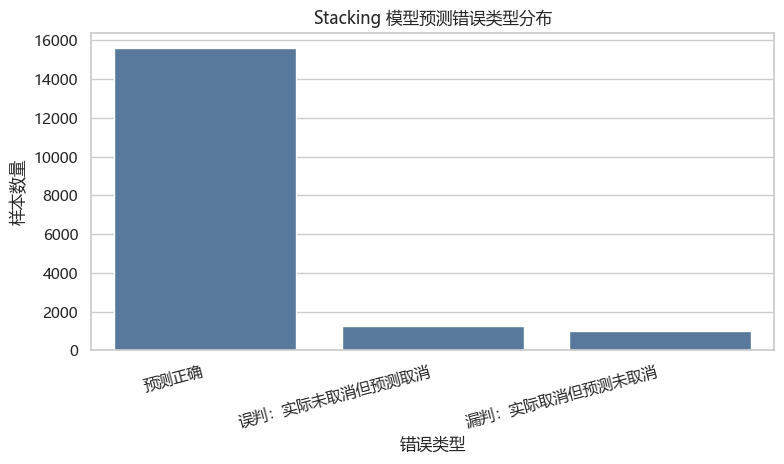

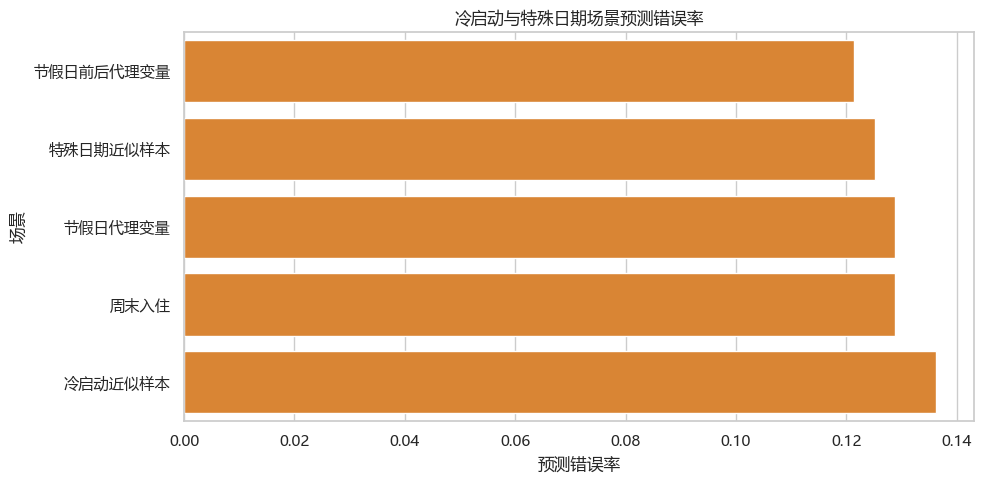

In [76]:
# 绘制错误类型分布和场景维度错误率图。
plt.figure(figsize=(8, 4.8))
sns.barplot(
    data=error_type_summary,
    x="error_type",
    y="sample_count",
    color="#4C78A8",
)
plt.title("Stacking 模型预测错误类型分布")
plt.xlabel("错误类型")
plt.ylabel("样本数量")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig(ERROR_TYPE_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 5))
scenario_plot_data = error_scenario_summary.sort_values(
    "scenario_error_rate",
    ascending=True,
)
sns.barplot(
    data=scenario_plot_data,
    x="scenario_error_rate",
    y="scenario",
    color="#F58518",
)
plt.title("冷启动与特殊日期场景预测错误率")
plt.xlabel("预测错误率")
plt.ylabel("场景")
plt.tight_layout()
plt.savefig(ERROR_SCENARIO_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()



In [77]:
# 在 Notebook 中展示错误类型、业务分组和场景维度的统计结果。
display(error_type_summary)
display(error_segment_summary.head(20))
display(error_scenario_summary)


,error_type,sample_count,sample_ratio
0,预测正确,15608,0.8735
1,误判：实际未取消但预测取消,1250,0.0700
2,漏判：实际取消但预测未取消,1010,0.0565


,segment_column,segment_value,sample_count,cancel_rate,avg_predicted_probability,error_count,error_rate,false_negative_count,false_positive_count
0,distribution_channel_group,GDS,28,0.2500,0.2315,7,0.2500,7,0
1,market_segment_group,Complementary,122,0.1639,0.2077,24,0.1967,18,6
2,market_segment_group,Online TA,8297,0.3586,0.4222,1597,0.1925,649,948
3,lead_time_group_label,8 30,2755,0.2740,0.3323,453,0.1644,223,230
4,lead_time_group_label,31 90,4446,0.3783,0.4338,703,0.1581,275,428
5,deposit_type_group,No Deposit,15509,0.2800,0.3324,2256,0.1455,1008,1248
6,customer_type_group,Transient,13324,0.4099,0.4590,1930,0.1449,856,1074
7,lead_time_group_label,91 180,3819,0.4629,0.5087,541,0.1417,200,341
8,hotel_type_group,City Hotel,12401,0.4159,0.4671,1698,0.1369,754,944
9,distribution_channel_group,TA TO,14703,0.4133,0.4581,1898,0.1291,751,1147


,scenario,scenario_count,scenario_cancel_rate,scenario_error_rate,non_scenario_count,non_scenario_cancel_rate,non_scenario_error_rate,error_rate_gap
0,冷启动近似样本,16315,0.3514,0.1363,1553,0.6072,0.0232,0.1131
1,特殊日期近似样本,10732,0.3709,0.1251,7136,0.3777,0.1285,-0.0034
2,周末入住,5460,0.3731,0.1288,12408,0.3739,0.1255,0.0033
3,节假日代理变量,5460,0.3731,0.1288,12408,0.3739,0.1255,0.0033
4,节假日前后代理变量,5272,0.3687,0.1214,12596,0.3757,0.1286,-0.0072


## 5. 业务落地模拟设计


### 5.1 取消风险评分生成


In [78]:
# 用 LightGBM 生成订单级取消风险评分，供业务模拟使用。
def split_feature_rows_by_time(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """按第二阶段相同时间窗口拆分特征工程后的原始业务字段。"""
    arrival_date = pd.to_datetime(data["arrival_date"])
    train_mask = arrival_date < pd.Timestamp("2024-09-01")
    validation_mask = (arrival_date >= pd.Timestamp("2024-09-01")) & (
        arrival_date < pd.Timestamp("2024-11-01")
    )
    test_mask = (arrival_date >= pd.Timestamp("2024-11-01")) & (
        arrival_date < pd.Timestamp("2025-01-01")
    )
    return data.loc[train_mask].copy(), data.loc[validation_mask].copy(), data.loc[test_mask].copy()


if RUN_BUSINESS_SIMULATION:
    best_params = pd.read_csv(OPTUNA_BEST_PARAMS_PATH)
    lightgbm_params = params_for_model(best_params, "LightGBM")
    business_model = build_best_model("LightGBM", lightgbm_params)
    business_model.fit(X_train, y_train)

    test_cancel_probability = business_model.predict_proba(X_test)[:, 1]

    feature_rows = pd.read_parquet(FEATURE_PARQUET_PATH)
    _, _, business_test_rows = split_feature_rows_by_time(feature_rows)
    business_test_rows = business_test_rows.reset_index(drop=True)

    business_risk_scores = business_test_rows[
        [
            "hotel",
            "hotel_type",
            "arrival_date",
            "lead_time",
            "market_segment",
            "distribution_channel",
            "customer_type",
            "deposit_type",
            "country",
            "agent",
            "adr",
            "estimated_revenue",
            TARGET_COLUMN,
        ]
    ].copy()
    business_risk_scores["cancel_risk_score"] = test_cancel_probability
    business_risk_scores["predicted_cancel"] = (
        business_risk_scores["cancel_risk_score"] >= 0.5
    ).astype(int)
    business_risk_scores.to_csv(
        BUSINESS_RISK_SCORE_PATH,
        index=False,
        encoding="utf-8-sig",
    )
else:
    business_risk_scores = pd.read_csv(BUSINESS_RISK_SCORE_PATH)

business_risk_scores.head(10)


,hotel,hotel_type,arrival_date,lead_time,market_segment,distribution_channel,customer_type,deposit_type,country,agent,adr,estimated_revenue,is_canceled,cancel_risk_score,predicted_cancel
0,Resort Hotel - Pune,Resort Hotel,2024-12-18,75,Offline TA/TO,TA/TO,Transient,No Deposit,PRT,15.0,105.50,316.50,1,0.654296,1
1,Resort Hotel - Chennai,Resort Hotel,2024-12-17,12,Online TA,TA/TO,Transient,No Deposit,IRL,240.0,88.20,88.20,0,0.024248,0
2,Resort Hotel - Delhi,Resort Hotel,2024-11-11,7,Direct,Direct,Transient,No Deposit,GBR,250.0,153.00,612.00,0,0.103738,0
3,Resort Hotel - Pune,Resort Hotel,2024-11-23,37,Online TA,TA/TO,Transient,No Deposit,GBR,241.0,97.29,486.45,0,0.006900,0
4,Resort Hotel - Pune,Resort Hotel,2024-12-01,48,Offline TA/TO,TA/TO,Contract,No Deposit,IRL,8.0,79.50,556.50,0,0.008491,0
5,Resort Hotel - Chennai,Resort Hotel,2024-11-03,60,Online TA,TA/TO,Transient,No Deposit,PRT,240.0,107.00,749.00,1,0.889132,1
6,Resort Hotel - Chandigarh,Resort Hotel,2024-11-01,70,Direct,Direct,Transient,No Deposit,ROU,250.0,137.00,685.00,0,0.148485,0
7,Resort Hotel - Goa,Resort Hotel,2024-12-28,50,Online TA,TA/TO,Transient,No Deposit,IRL,241.0,119.35,835.45,0,0.002552,0
8,Resort Hotel - Bhopal,Resort Hotel,2024-11-05,1,Online TA,TA/TO,Transient,No Deposit,ARG,240.0,147.00,147.00,0,0.001957,0
9,Resort Hotel - Mumbai,Resort Hotel,2024-11-21,0,Direct,Direct,Transient,No Deposit,PRT,0.0,123.00,123.00,0,0.215286,0


### 5.2 风险分层统计


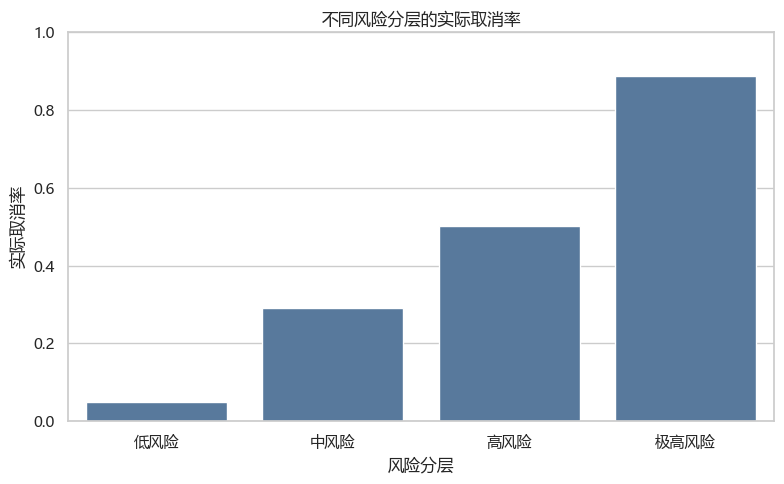

,risk_segment,order_count,canceled_count,actual_cancel_rate,avg_risk_score,avg_adr,avg_estimated_revenue,order_share
0,低风险,9029,441,0.048843,0.067645,92.124427,275.140901,0.505317
1,中风险,1802,526,0.291898,0.395348,111.926232,347.325189,0.100851
2,高风险,1396,701,0.502149,0.595619,106.330322,348.964097,0.078128
3,极高风险,5641,5008,0.887786,0.922669,98.743148,319.343053,0.315704


In [79]:
# 按取消风险分数切分风险等级，并统计各风险层的实际取消情况。
RISK_SEGMENT_BINS = [0.0, 0.3, 0.5, 0.7, 1.0]
RISK_SEGMENT_LABELS = ["低风险", "中风险", "高风险", "极高风险"]

business_risk_scores["risk_segment"] = pd.cut(
    business_risk_scores["cancel_risk_score"],
    bins=RISK_SEGMENT_BINS,
    labels=RISK_SEGMENT_LABELS,
    include_lowest=True,
    right=False,
)

risk_segment_summary = (
    business_risk_scores.groupby("risk_segment", observed=False)
    .agg(
        order_count=(TARGET_COLUMN, "size"),
        canceled_count=(TARGET_COLUMN, "sum"),
        actual_cancel_rate=(TARGET_COLUMN, "mean"),
        avg_risk_score=("cancel_risk_score", "mean"),
        avg_adr=("adr", "mean"),
        avg_estimated_revenue=("estimated_revenue", "mean"),
    )
    .reset_index()
)
risk_segment_summary["order_share"] = (
    risk_segment_summary["order_count"] / business_risk_scores.shape[0]
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=risk_segment_summary,
    x="risk_segment",
    y="actual_cancel_rate",
    color="#4C78A8",
)
plt.ylim(0, 1)
plt.title("不同风险分层的实际取消率")
plt.xlabel("风险分层")
plt.ylabel("实际取消率")
plt.tight_layout()
plt.savefig(BUSINESS_RISK_SEGMENT_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

display(risk_segment_summary)


### 5.3 干预阈值与业务收益模拟


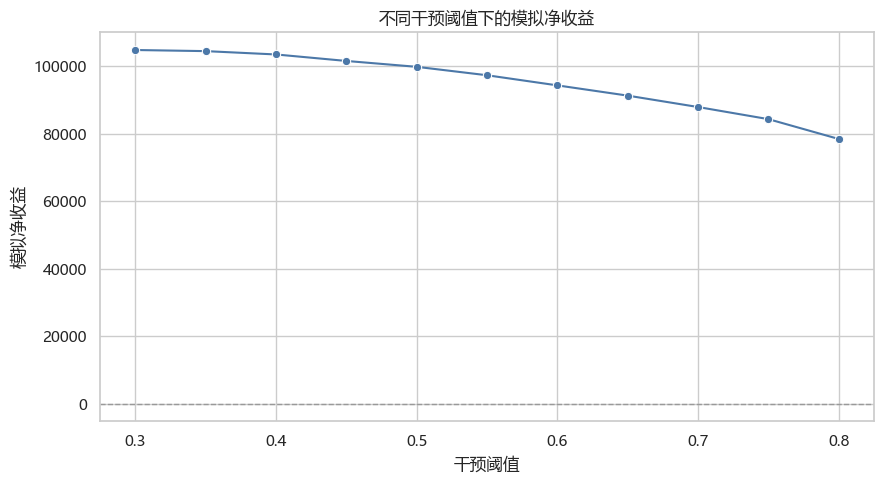

,threshold,touched_orders,touch_rate,touched_canceled_orders,cancel_recall,precision,estimated_saved_orders,estimated_saved_revenue,intervention_cost,estimated_net_benefit
0,0.30,8839,0.4947,6235,0.9339,0.7054,935.25,148944.98,44195.0,104749.98
1,0.35,8350,0.4673,6135,0.9190,0.7347,920.25,146169.98,41750.0,104419.98
2,0.40,7893,0.4417,6003,0.8992,0.7605,900.45,142895.95,39465.0,103430.95
3,0.45,7413,0.4149,5850,0.8763,0.7892,877.50,138572.38,37065.0,101507.38
4,0.50,7037,0.3938,5709,0.8552,0.8113,856.35,134953.50,35185.0,99768.50
5,0.55,6635,0.3713,5540,0.8298,0.8350,831.00,130447.35,33175.0,97272.35
6,0.60,6305,0.3529,5369,0.8042,0.8515,805.35,125794.80,31525.0,94269.80
7,0.65,5959,0.3335,5181,0.7761,0.8694,777.15,121029.51,29795.0,91234.51
8,0.70,5641,0.3157,5008,0.7501,0.8878,751.20,116060.35,28205.0,87855.35
9,0.75,5338,0.2987,4819,0.7218,0.9028,722.85,110955.12,26690.0,84265.12


,threshold,touched_orders,touch_rate,touched_canceled_orders,cancel_recall,precision,estimated_saved_orders,estimated_saved_revenue,intervention_cost,estimated_net_benefit
0,0.3,8839,0.4947,6235,0.9339,0.7054,935.25,148944.98,44195.0,104749.98


In [80]:
# 用简化参数模拟不同干预阈值下的潜在净收益。
SIMULATED_INTERVENTION_COST = 5.0
SIMULATED_SAVE_RATE = 0.15
SIMULATED_REVENUE_SAVE_RATIO = 0.5


def simulate_business_thresholds(
    risk_scores: pd.DataFrame,
    thresholds: np.ndarray,
) -> pd.DataFrame:
    """在不同干预阈值下模拟覆盖率、召回率和净收益。"""
    records = []
    actual_canceled = risk_scores[TARGET_COLUMN].astype(int)
    total_canceled = int(actual_canceled.sum())

    for threshold in thresholds:
        intervention_mask = risk_scores["cancel_risk_score"] >= threshold
        touched_orders = int(intervention_mask.sum())
        touched_canceled_orders = int((actual_canceled & intervention_mask).sum())
        estimated_saved_orders = touched_canceled_orders * SIMULATED_SAVE_RATE
        estimated_saved_revenue = (
            risk_scores.loc[intervention_mask & actual_canceled.astype(bool), "estimated_revenue"].sum()
            * SIMULATED_SAVE_RATE
            * SIMULATED_REVENUE_SAVE_RATIO
        )
        intervention_cost = touched_orders * SIMULATED_INTERVENTION_COST
        estimated_net_benefit = estimated_saved_revenue - intervention_cost
        records.append(
            {
                "threshold": round(float(threshold), 2),
                "touched_orders": touched_orders,
                "touch_rate": round(touched_orders / risk_scores.shape[0], 4),
                "touched_canceled_orders": touched_canceled_orders,
                "cancel_recall": round(touched_canceled_orders / total_canceled, 4),
                "precision": round(
                    touched_canceled_orders / touched_orders if touched_orders else 0,
                    4,
                ),
                "estimated_saved_orders": round(estimated_saved_orders, 2),
                "estimated_saved_revenue": round(float(estimated_saved_revenue), 2),
                "intervention_cost": round(intervention_cost, 2),
                "estimated_net_benefit": round(float(estimated_net_benefit), 2),
            }
        )
    return pd.DataFrame(records)


if RUN_BUSINESS_SIMULATION:
    threshold_values = np.arange(0.30, 0.81, 0.05)
    threshold_simulation = simulate_business_thresholds(
        business_risk_scores,
        threshold_values,
    )
    threshold_simulation.to_csv(
        BUSINESS_THRESHOLD_SIMULATION_PATH,
        index=False,
        encoding="utf-8-sig",
    )
else:
    threshold_simulation = pd.read_csv(BUSINESS_THRESHOLD_SIMULATION_PATH)

plt.figure(figsize=(9, 5))
sns.lineplot(
    data=threshold_simulation,
    x="threshold",
    y="estimated_net_benefit",
    marker="o",
    color="#4C78A8",
)
plt.axhline(0, color="#999999", linestyle="--", linewidth=1)
plt.title("不同干预阈值下的模拟净收益")
plt.xlabel("干预阈值")
plt.ylabel("模拟净收益")
plt.tight_layout()
plt.savefig(BUSINESS_THRESHOLD_FIGURE_PATH, dpi=160, bbox_inches="tight")
plt.show()

best_threshold_row = threshold_simulation.sort_values(
    "estimated_net_benefit",
    ascending=False,
).head(1)

display(threshold_simulation)
display(best_threshold_row)
